# <p align = "center"> Protein Conformation Analysis </p>
## <p align = "center"> B-factors </p>

### Summary:

In this notebook, we will be looking at the b-factors of the proteins. This will include:

- <ins> different types of b-factors </ins>: **raw b-factors** VS **normalized b-factors** | **atom-level b-factors** VS **residue-level b-factors** VS **protein subunit-level b-factors** 

- <ins> different protein conformations </ins>: **apo-proteins** | **holo-proteins**;

- <ins> different levels of protein detail </ins>: **whole protein** | **binding site** | **Interacting A.A.s**

<br>

To do this efficiently, a certain level of **Protein Files Preprocessing** will be happening as well as **Programmatic Tools Development** alongside as needed. This will ensure data quality, linkage, and sanity. 

<br>

### Tasks:

All together, a certain number of tasks will have to be performed as follows:

- Analyse and Understand PDB File Structures, and Understand Idiosyncracies:

    - 1 Prot Subunit + 1 Ligand | Multi Copies of Prot Subunit + 1 Ligand | Multi Copies of Prot Subunit + Multi Copies Ligand 

- Check for Data Assumptions

    - Ensure Consistent Labelling
    
        - Define a Reference Protein

        - Ensure Consistent Protein Amino Acid Indexing

        - Ensure Consistent Protein Labelling

        - Ensure Consistent Ligand Labelling (e.g. ligand = "LIG")

    - Ensure Consistent Protein Alignment

    - Ensure Consistent PDB Content - e.g. (1 protein subunit + 1 Ligand + waters)

- Extract PDB Data Components into Separate Objects: **Ligand** | **Waters** | **Protein Subunits** | **Protein Quaternary Structure**

- Identify Amino Acids at Different Levels (protein subunit | binding site | interacting a.a.s)

    - Define Binding Site

    - Define Interacting a.a.s 

- Calculate Different types of b-factors for different types of amino acid levels: raw- VS normalized- | residue-level VS subunit-level

<br>

### Output:

As a result of the data preprocessing new files have been created and old ones have been modified:

In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt
import matplotlib.gridspec  as gridspec

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

# Looking at natural flexibility of Ground-state Active Site



- ## Load And Pre-process Relevant Data

In [2]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)

# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragalysis Ligand Files
piperidLigPath = rootProjDir / "02-chemofint/piperidir_lig.sdf"
piperidLigs = Chem.SDMolSupplier( str(piperidLigPath), removeHs=False)


## - Analysing Ligands Data

In [3]:
print("Number of Piperidine Ligands: {}".format( len( list( piperidLigs ) ) ) )
print( "Number of Piperidine bound Proteins: {}".format( len( list( piperid_dir.iterdir() ) ) ) )
print("Number of Duplicates: {}".format(len( list( piperidLigs ) ) - len( list( piperid_dir.iterdir() ) ) ))


Number of Piperidine Ligands: 460
Number of Piperidine bound Proteins: 454
Number of Duplicates: 6


### <ins>Looking at the Nature of Duplicates</ins> - Conformers

In [4]:
# input_files = [ str(piperid_dir / code / f"{code}.sdf") for code in pipedirine_codes ]
lst_datasets = []
for dir in piperid_dir.iterdir():
    filename = dir.joinpath( "{}{}".format(dir.name, ".sdf") )
    supplier = Chem.SDMolSupplier(filename)
    if len(supplier) > 1: 
        lst_datasets.append(dir.name)
        # print("File Path: ", filename)
        # print("Molec Entity Count: ", len(supplier))
        # smiles_set = set()
        # for mol in supplier:
        #     smiles_set.add( Chem.MolToSmiles(mol))
        # if len(smiles_set) == 1: print("Molec Entity Type: Conformers of the same molecule")
        # elif len(smiles_set) >1: print("Molec Entity Type: Different Molecule")
        # else: print("something funky in here")

print( lst_datasets )

['A4237b', 'A4998a', 'A4715a', 'A4237a', 'A3618a', 'A4674b']


A quick anecdotal look at one dataset shows, that the `.pdb` file contains the ligand as one state with 50-50 occupancy, while the `.sdf`is split into two by PyMol and rdkit.

The pictures does not show, it was observed that the sdf ligands are co-localized at the same region, similarly to the `.pdb` picture.

<img src="../../../../images/piperid/pip_multi_conf.png" width="20%" >

### Check how many of the piperidine ligands are NOT localized in the main binding site

### - Calculate mean CoM for all ligands (mean_CoM)

In [5]:
# Calculate mean CoM for all ligands (mean_CoM)
from xaidar.data.molecModels import rdkit_to_gemmi

lst_ligs = [ flatten_pdb( lig_pdb, "residue")[0] for lig_pdb in rdkit_to_gemmi(piperidLigs)]
CoM_array = get_res_CoM(  lst_ligs  )
# print( "Ligands CoM array shape: ", CoM_array.shape)
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
print( "Mean CoM from all ligands: ",mean_CoM )

Mean CoM from all ligands:  <gemmi.Position(8.93134, 13.2798, 23.3181)>


### - Calculate mean CoM for Piperidine Ligands (mean_CoM)

<details open>
<summary> Steps: </summary>

- Get CoM for Piperidines from datasets with one unique subset

    - Frequency shows this accounts for a significant amount of piperidines (242 / 347)

    - Histogram shows that datasets with single subsets co-localize in the same region (prob ensured by XCA)

- Use this CoM to subset with Piperidine closests to the CoM

    - Histogram shows again that these are all quite close to each other, suggesting that for each dataset, there is always one subset with a piperidine bound to the main binding site

- Update the CoM for the co-localized Filtered Piperidines
</details>

In [6]:
rootdir
piperid_dir = rootdir.joinpath( "data/ev2a/fragalysis/02-chemofint/piperid")

# Get name of datasets with and without multiplicity
from collections import defaultdict
multiplicity_counter = defaultdict(list)
for item in  piperid_dir.iterdir(): multiplicity_counter[item.name[:-1]].append( item.name )

single_datasets = { dataset : lst_subsets for dataset, lst_subsets in multiplicity_counter.items() if len(lst_subsets) == 1 } 
multiple_datasets =  { dataset : lst_subsets for dataset, lst_subsets in multiplicity_counter.items() if len(lst_subsets) > 1 } 

print("Number of datasets with single subsets:   {}".format( single_datasets.__len__() ) )
print("Number of datasets with mulitple subsets: {}".format( multiple_datasets.__len__()) )
print("Total Number of unique datasets: \t  {}".format( single_datasets.__len__()  +  multiple_datasets.__len__() ))

Number of datasets with single subsets:   242
Number of datasets with mulitple subsets: 105
Total Number of unique datasets: 	  347


In [7]:
# Get Ligands with no multiplicity
lst_piperids = dict()
for pip_folder in sorted([ lst_subsets[0] for lst_subsets in single_datasets.values()]):
    pip = loadPDB( piperid_dir.joinpath( f"{pip_folder}", "{}{}".format(pip_folder,"_ligand.pdb" )) )
    # pip = sele_pdb(pip, sele_Lig)
    lst_piperids[ f"{pip_folder}"] = pip
print(lst_piperids.__len__())

242


In [8]:
# Calculate the CoM for each Piperidine
CoM_array = np.array( [ flatten_pdb(  lig, "chain")[0].calculate_center_of_mass().tolist() for lig in lst_piperids.values()  ] )

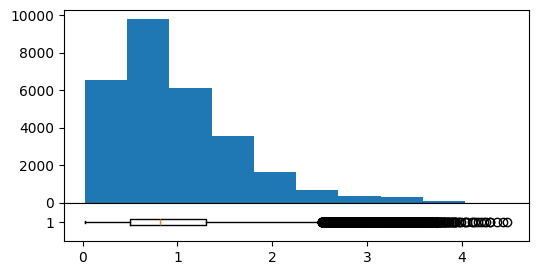

In [9]:
# Look at the distance between each piperidine
array1 = np.expand_dims( CoM_array, axis = (1,))
array2 =  np.expand_dims( CoM_array, axis = (0,))
array3 = array1 - array2
array4 = np.linalg.norm( array3, axis = 2 )
array5 = np.triu( array4, k=0)
array6 = np.matrix.flatten(array5)
array6 = array6[ np.nonzero(array6)]

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
# gs = gridspec.GridSpec( 2,1, height_ratios=(2,1) )
ax[0].hist( array6 )
ax[1].boxplot( array6, vert = False)
plt.subplots_adjust( hspace=0)
plt.show()

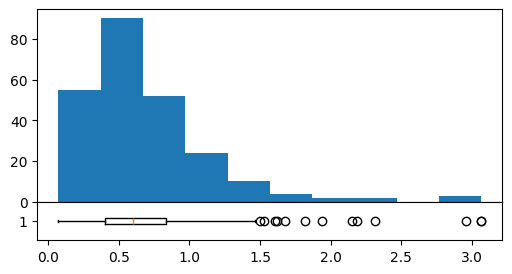

In [10]:
# Calculate mean center of mass for ligands without multiplicity
mean_CoM = CoM_array.mean( axis=0)
gemmi_mean_CoM = gemmi.Position( *mean_CoM.tolist() )

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
ax[0].hist( np.linalg.norm(CoM_array - mean_CoM, axis = 1) )
ax[1].boxplot( np.linalg.norm(CoM_array - mean_CoM, axis = 1), vert = False)
plt.subplots_adjust( hspace=0)
plt.show()


All CoM are within the same space

347


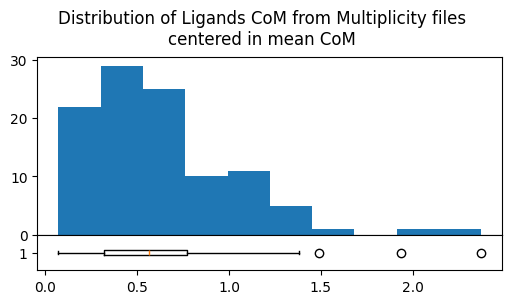

In [11]:
# Get ligand with shortest CoM from mean CoM
count = 0
dataset_names = list()
lst_CoM_dist = dict()
for dataset, lst_subsets in multiple_datasets.items():
    subset_names = sorted( lst_subsets )

    closest_subset_name = subset_names[0]
    closest_subset_obj = loadPDB( piperid_dir.joinpath( f"{subset_names[0]}",f"{subset_names[0]}_ligand.pdb") )
    closests_CoM = flatten_pdb( closest_subset_obj, "chain")[0].calculate_center_of_mass().dist(gemmi_mean_CoM)

    for subset_name in subset_names:
        tmp_lig_pdb = loadPDB( piperid_dir.joinpath( f"{subset_name}",f"{subset_name}_ligand.pdb"))
        CoM = flatten_pdb( tmp_lig_pdb, "chain")[0].calculate_center_of_mass()

        if CoM.dist( gemmi_mean_CoM ) < closests_CoM:
            closests_CoM = CoM.dist( gemmi_mean_CoM )
            closest_subset_name = subset_name
            closest_subset_obj = tmp_lig_pdb

    lst_piperids[closest_subset_name] = closest_subset_obj
    lst_CoM_dist[closest_subset_name] = closests_CoM

print( len( lst_piperids))

fig, ax = plt.subplots( 2, 1, figsize = (6, 3), sharex=True, gridspec_kw={"height_ratios":[5,1]} ) 
lst_CoM_dist = [ closests_CoM for closests_CoM in lst_CoM_dist.values()]
ax[0].hist( lst_CoM_dist)
ax[1].boxplot( lst_CoM_dist, vert = False)
plt.subplots_adjust( hspace=0, top = 0.82)
plt.suptitle("Distribution of Ligands CoM from Multiplicity files\ncentered in mean CoM")
plt.show()



#### Get Updated Center of Mass

In [12]:
updated_CoM_array = np.array( [ flatten_pdb(  lig, "chain")[0].calculate_center_of_mass().tolist() for lig in lst_piperids.values()  ] )
updated_mean_CoM = updated_CoM_array.mean( axis=0)
updated_gemmi_mean_CoM = gemmi.Position( *updated_mean_CoM.tolist() )

### - Get Index for amino acids in the Binding Site

<details open>
<summary> Steps: </summary>

- Pick a reference protein and filter it

    - Reference Protein (A0926) only has one subset

    - Reference Protein ligand binds closests to one of the protein chains (see Image bellow)
    
    - Extract the chain which the binding site closest to the piperidines

- Get Ref Prot Amino Acids Indexes within 4 Angstorms from any Piperidine

</details>

#### Image of Reference Protein PDB File


<img src="../../../../images/piperid/reference_prot.png" width="7%" >

#### Get Index for amino acids in the Binding Site


In [13]:
from xaidar.data.molecModels import sele_closest_Chain, clear_empty
ref_pdb = loadPDB( rootdir.joinpath("data/ev2a/fragalysis/02-chemofint/reference/A0926a.pdb") )
# get_pdb_stats( ref_pdb)

ref_lig = sele_pdb( ref_pdb, sele_Lig)
ref_lig_CoM = flatten_pdb( ref_lig, "chain")[0].calculate_center_of_mass()

ref_prots = sele_pdb(ref_pdb, sele_AA )
closest_chain = sele_closest_Chain(flatten_pdb( ref_prots, "chain"), ref_lig_CoM )
# print( "\n############\nClosest Prot Chain to Lig: ",closest_chain[0].name)

ref_prot = createPDB(chainList = closest_chain )
ref_prot = clear_empty( ref_prot )
# get_pdb_stats( ref_prot)

In [14]:
from xaidar.data.molecModels import get_pairwise_dist
ligs_datasets, ligs_res_lst = zip( *[[dataset, flatten_pdb(lig_obj, "residue")[0] ] for dataset, lig_obj in lst_piperids.items() ])
print( len(ligs_datasets), len(ligs_res_lst))
print( ligs_datasets[0], ligs_res_lst[0])

ref_prot_chains = flatten_pdb( ref_prot, "chain")


activesite_aa_set = set()
activesite_aa_set_idx = set()
activesite_aa_per_dataset = defaultdict( list)
for chain in ref_prot_chains:                                                       # There is only one chain
                                                                                    # First Filter By Residue Distance
    res_CoMs = get_res_CoM( chain.whole() )
    res_lst  = [ (idx, res) for idx, res in enumerate(chain.whole()) if np.linalg.norm( res_CoMs[idx] - updated_mean_CoM) < 15.0 ]
    for res_idx, prot_res in res_lst:                                                    # 
        res_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  prot_res] )
                                                                                    # Then, filter by atom distance
        for lig_res, lig_dataset_name in zip(ligs_res_lst,ligs_datasets ):          # Ligands
          lig_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  lig_res] )
          if np.min( get_pairwise_dist(res_atom_pos, lig_atom_pos) ) < 4.0:         # Amino acids within 4A of ligand
              activesite_aa_set.add( prot_res )
              activesite_aa_set_idx.add(res_idx)
              activesite_aa_per_dataset[lig_dataset_name].append( prot_res ) 

print(sorted([ (res.name, res.seqid.num) for res in activesite_aa_set], key = lambda res: res[1] ))
print( activesite_aa_set_idx)

347 347
A0926a 250(LIG)
[('HIS', 21), ('ASP', 39), ('VAL', 84), ('GLU', 85), ('ALA', 86), ('SER', 87), ('GLU', 88), ('TYR', 89), ('TYR', 90), ('ARG', 93), ('GLN', 95), ('SER', 105), ('GLU', 106), ('PRO', 107), ('GLY', 108), ('ASP', 109), ('CYS', 110), ('VAL', 124), ('SER', 125), ('THR', 126), ('GLY', 127), ('GLY', 128), ('ASN', 129)]
{14, 32, 77, 78, 79, 80, 81, 82, 83, 86, 88, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122}


### - Filter Piperidine Proteins

So far we have filter the subsets so that we have the subset where the piperidine binds at the binding site

Now, we gonna filter those subsets with multiple proteins, by picking the chain with the Binding Site Residues CoM closest to the Piperidine CoM

Why we use indexes to filter?

- Previous analysis (02.2) shows that when aligned all proteins have the same starting point, that there is no deletions or insertions between the proteins up untill the index 132.

In [15]:
def sele_chain_name( lst_chain: list[gemmi.Chain], level = False, chain_name: 
                                str | list[str]  = None):
    """Helper function of sele_pdb, used to extract one or several
    chains into a pdb object based off of their
    """
    if level: return "chain"
    if isinstance( chain_name, str): chain_name = list(chain_name )
    return [ chain for chain in lst_chain if chain.name in chain_name]


lst_subsets = list(lst_piperids.keys())
lst_pip_prots = dict()


for subset in lst_subsets:
    pip_pdb = loadPDB( piperid_dir.joinpath( f"{subset}/{subset}.pdb" ) )
    pip_prot = sele_pdb(pip_pdb, sele_AA)

    if len( pip_prot[0]) > 1:                                                  
        shortest_dist_from_pip_mean_CoM = 100000000                             # Set arbitrarily large number so that any 
        for chain in pip_prot[0]:                                               # Check if there are chains in subset closer to 
            prot_res_lst = chain.whole()                                        # Get list of all residues
            prot_bind_site_res = [ res for id , res in 
                enumerate( prot_res_lst ) if id in activesite_aa_set_idx]       # Get binding site amino acids only 
            prot_bind_site_chain = gemmi.Chain("A")                             # Create an emtpy gemmi obj to save residues
            prot_bind_site_chain.append_residues(prot_bind_site_res)            # Save list of residues to gemmi obj
            prot_bind_site_chain_CoM = prot_bind_site_chain.calculate_center_of_mass()  # Get center of mass of binding
            dist_from_pip_mean_CoM = updated_gemmi_mean_CoM.dist( prot_bind_site_chain_CoM)
            if dist_from_pip_mean_CoM < shortest_dist_from_pip_mean_CoM:
                shortest_chain_name = chain.name


        pip_prot = sele_pdb( pip_prot, sele_chain_name, chain_name = shortest_chain_name ) 
        pip_prot = clear_empty( pip_prot)
        lst_pip_prots[subset] = {f"Chain_{pip_prot[0][0].name}": pip_prot}

    elif len( pip_prot[0]) == 1:
        lst_pip_prots[subset] = {f"Chain_{pip_prot[0][0].name}": pip_prot}
    else:
        Exception( f"There are no AA chains in dataset:  {subset}")

print( len(lst_pip_prots))

347


### - Filter Non-Piperidine Proteins -> Chain with CoM closests to Ref Protein CoM

Per dataset:

- Check if one subset with one chain

    IF not:

    - 

- Keep track on the variation of CoM and rmsd between chains in the same dataset


In [16]:
from collections import defaultdict


from xaidar.data.molecModels import sele_chain_idx

chem_series_dirs = ["fragscreen", "nonactivesite"]
rootdir.joinpath("data/ev2a/fragalysis/02-chemofint")
ref_prot
ref_prot_CoM = flatten_pdb( ref_prot, "chain")[0].calculate_center_of_mass()

proteins_dict = dict( )
for chem_series_type in chem_series_dirs:
    proteins_dict[chem_series_type] =  dict()

    chem_series_dir = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint", chem_series_type)
    dataset_subset_dir = defaultdict(list)
    for subset in chem_series_dir.iterdir(): 
        if subset.is_dir: dataset_subset_dir[ subset.name[:-1]].append(subset.name)
    
    for dataset, lst_subsets in dataset_subset_dir.items():
        if len(lst_subsets) == 1:
            subset = lst_subsets[0]
            get_closest_prot( chem_series_type, subset, ref_prot_CoM,  proteins_dict )



    
    pass


            pdb = loadPDB( chem_series_dir.joinpath( subset, f"{lst_subsets}.pdb") )
            prots = sele_pdb( pdb, sele_AA)

            if len(prots[0]) == 1:
                proteins_dict[ "chem_series_type"][subset] = prots[0]

            elif len(prots[0]) > 1:
                lst_prots = [ sele_pdb( prots, sele_chain_idx, lst_idx = [idx] )
                              for idx in range( len(prots[0]) )  ]
                shortest_dist_ref = 100000000
                for prot in lst_prots:
                    prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
                    CoM_diff = prot_CoM.dist( ref_prot_CoM )
                    if CoM_diff < shortest_dist_ref:
                        shortest_dist_ref = CoM_diff
                        closest_prot = prot

                proteins_dict[ "chem_series_type"][subset] = closest_prot
                           
            else:
                raise Exception( "The following subset is missing proteins: {subset}")

IndentationError: unexpected indent (1221532043.py, line 31)

In [17]:
from xaidar.data.molecModels import sele_chain_idx

chem_series_dirs = ["fragscreen", "nonactivesite"]
rootdir.joinpath("data/ev2a/fragalysis/02-chemofint")
ref_prot
ref_prot_CoM = flatten_pdb( ref_prot, "chain")[0].calculate_center_of_mass()


def get_closest_prot(subset_name, ref_prot_CoM ):
    pdb = loadPDB( chem_series_dir.joinpath( subset_name, f"{subset_name}.pdb") )
    prots = sele_pdb( pdb, sele_AA)

    if len(prots[0]) == 1:
        prot_CoM = flatten_pdb( prots, "chain")[0].calculate_center_of_mass()
        CoM_diff = prot_CoM.dist( ref_prot_CoM )
        return prots[0], CoM_diff

    elif len(prots[0]) > 1:
        lst_prots = [ sele_pdb( prots, sele_chain_idx, lst_idx = [idx] )
                        for idx in range( len(prots[0]) )  ]
        shortest_dist_ref = 100000000
        for prot in lst_prots:
            prot_CoM = flatten_pdb( prot, "chain")[0].calculate_center_of_mass()
            CoM_diff = prot_CoM.dist( ref_prot_CoM )
            if CoM_diff < shortest_dist_ref:
                shortest_dist_ref = CoM_diff
                closest_prot = prot
            
        return closest_prot, shortest_dist_ref
                           
    else:
        raise Exception( "The following subset is missing proteins: {subset}")


proteins_dict = dict( )
for chem_series_type in chem_series_dirs:
    proteins_dict[chem_series_type] =  dict()

    chem_series_dir = rootdir.joinpath("data/ev2a/fragalysis/02-chemofint", chem_series_type)
    dataset_subset_dir = defaultdict(list)
    for subset in chem_series_dir.iterdir(): 
        if subset.is_dir: dataset_subset_dir[ subset.name[:-1]].append(subset.name)
    
    for dataset, lst_subsets in dataset_subset_dir.items():
        if len(lst_subsets) == 1:
            subset = lst_subsets[0]
            closest_subset_prot, _ = get_closest_prot(subset, ref_prot_CoM)
            proteins_dict[ chem_series_type][subset] = closest_subset_prot

        elif len(lst_subsets) > 1:
            shortest_dist = 100000000
            for subset in lst_subsets:
                closest_subset_prot, shortest_subset_dist = get_closest_prot( subset, ref_prot_CoM, )
                if shortest_subset_dist < shortest_dist:
                    closest_subset = subset
                    closest_prot = closest_subset_prot
            proteins_dict[ chem_series_type][closest_subset] = closest_prot
        else:
            raise Exception( "The following dataset is missing subsets: {dataset}")



In [18]:
print( "Length of frag screen unique subsets: {}".format( len( proteins_dict["fragscreen"] )))
print( "Length of nonactive unique subsets: {}".format( len( proteins_dict["nonactivesite"] )))        

print("#########")
print("Length of frag screen unique subsets: {}".format(
    len( set( [ item.name[:-1] for item in rootdir.joinpath("data/ev2a/fragalysis/02-chemofint","fragscreen").iterdir()] )) 
) )
print( "Length of nonactive unique subsets: {}".format( 
        len( set( [ item.name[:-1] for item in rootdir.joinpath("data/ev2a/fragalysis/02-chemofint","nonactivesite").iterdir()] )) 
) ) 

Length of frag screen unique subsets: 41
Length of nonactive unique subsets: 79
#########
Length of frag screen unique subsets: 41
Length of nonactive unique subsets: 79


In [19]:
# Filter Protein Sequences to only chains closest to the ligands mean CoM -> (lst_prots, prot_logs)
from xaidar.data.protocols import load_and_filter_Proteins

nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

print("\t\t       #Dirs  #AfterFilter")
print( "Nonactive Proteins:\t{}\t{}".format(len(list(nonactivepdbs_dir.iterdir())),
                                             len(nonactive_prots)))
print("FragScreen Proteins:\t{}\t{}".format(len(list(fragscreen_dir.iterdir())),
                                            len(fragscreen_prots)))
print("Piperid Proteins:  \t{}\t{}".format(len(list(piperid_dir.iterdir())),
                                           len(piperid_prots)))


		       #Dirs  #AfterFilter
Nonactive Proteins:	99	99
FragScreen Proteins:	42	42
Piperid Proteins:  	454	454


- ## Get Query AAs against Ref AAs 

In [20]:
# Get stats for reference protein
from xaidar.data.molecModels import get_chain_seq
ref_prot = fragscreen_prots[0].clone()
ref_seq = get_chain_seq( ref_prot)[0]
print( "Length of Ref Seq: ", len(ref_seq))
get_pdb_stats( ref_prot )

Length of Ref Seq:  140

####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: set()
	Contains A.A.


In [21]:
from xaidar.data.molecModels import model_seqAlign, get_aa_distribution
active_site_res_idxs  = [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126]
not_active_site_res_idxs =  [ idx for idx in range(len(ref_prot[0]["A"])) if idx not in active_site_res_idxs]

nonactive_aa_distrib_dict = get_aa_distribution( ref_prot, nonactive_prots, )
fragscreen_aa_distrib_dict = get_aa_distribution( ref_prot, fragscreen_prots, )
piperid_aa_distrib_dict = get_aa_distribution( ref_prot, piperid_prots,)

- ## Extract b-factor Values, Mean, and Std per amino acid

In [22]:
# Calculate b-factors for all residue sequences in nonactive_aa_distrib_dict
from xaidar.data.molecModels import get_res_bfactors

aa_distrib_lst = [ nonactive_aa_distrib_dict, fragscreen_aa_distrib_dict,
                   piperid_aa_distrib_dict ]
prot_names = ["Nonactive", "FragScreen", "Piperid" ]
aa_distrib_dict = {}
for aa_distrib, name in zip( aa_distrib_lst , prot_names):
    print("Calculating b-factors for {} dataset".format(name))

    res_seqs = list( zip( *aa_distrib.values()) ) # nonactive_aa_distrib_dict
    all_seqs_bfactors = []
    for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
    all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                            for seq_bfactors in all_seqs_bfactors ]
    aa_distrib_dict[name] = all_seqs_bfactors

print()
for name in prot_names:
    print( f"{name} number of residue sequences: ", len(aa_distrib_dict[name]))

print( "\nNumber of residue sequences: ", len(aa_distrib_dict["Nonactive"]))
print( "Number of residues per sequence: ", len(aa_distrib_dict["Nonactive"][0]) )
print( "First 10 residue b-factors: ", aa_distrib_dict["Nonactive"][0][:10])

Calculating b-factors for Nonactive dataset
Calculating b-factors for FragScreen dataset
Calculating b-factors for Piperid dataset

Nonactive number of residue sequences:  99
FragScreen number of residue sequences:  42
Piperid number of residue sequences:  454

Number of residue sequences:  99
Number of residues per sequence:  140
First 10 residue b-factors:  [16.435, 14.0975, 13.116, 12.4375, 16.83083, 16.96429, 18.4375, 23.0575, 19.07, 14.48818]


In [23]:
# Calcluate mean and std dev of b-factors at each residue position across all sequences
all_bfactor_dict = {}

for dataset_name in aa_distrib_dict.keys():
    bfactor_dict = {}
    bfactor_dict["values"] = np.array( aa_distrib_dict[dataset_name] )
    bfactor_dict["mean"] = np.nanmean( bfactor_dict["values"], axis=0)
    bfactor_dict["std"] = np.nanstd( bfactor_dict["values"], axis=0)
    all_bfactor_dict[ dataset_name ] = bfactor_dict

# bfactor_values = np.array( all_seqs_bfactors )
# bfactor_mean = np.nanmean(bfactor_values, axis=0)
# bfactor_std = np.nanstd(bfactor_values, axis=0)
for name in prot_names:
    print( f"{name} Bfactor values array shape: ", all_bfactor_dict[name]["values"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor means array shape: ", all_bfactor_dict[name]["mean"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor std array shape: ", all_bfactor_dict[name]["std"].shape )


Nonactive Bfactor values array shape:  (99, 140)
FragScreen Bfactor values array shape:  (42, 140)
Piperid Bfactor values array shape:  (454, 140)

Nonactive Bfactor means array shape:  (140,)
FragScreen Bfactor means array shape:  (140,)
Piperid Bfactor means array shape:  (140,)

Nonactive Bfactor std array shape:  (140,)
FragScreen Bfactor std array shape:  (140,)
Piperid Bfactor std array shape:  (140,)


- ## Plot extracted b-factor Values, Mean, and Std per amino acid

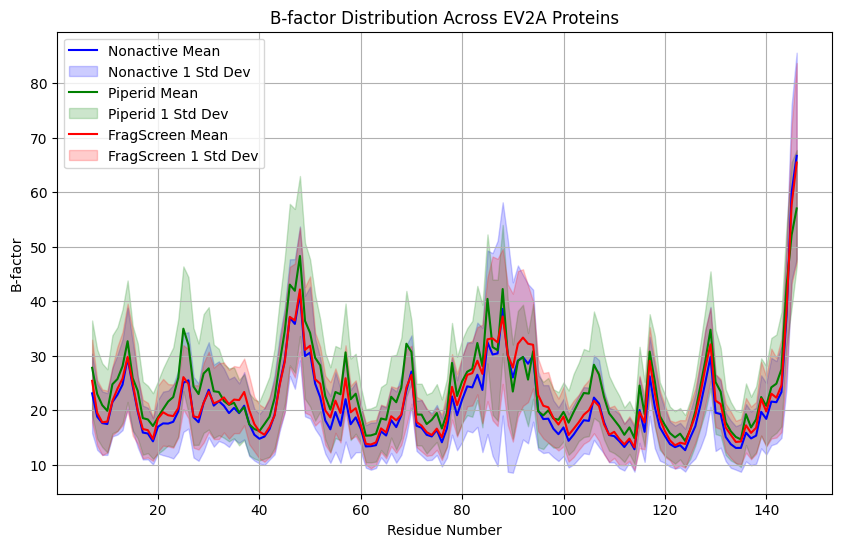

In [24]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
plt.figure(figsize=(10,6))
for dataset_name, color in zip(["Nonactive", "Piperid","FragScreen",  ][:], ['blue', 'green', 'red'][:]):
    bfactor_mean = all_bfactor_dict[ dataset_name ]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["std"]
    plt.plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
             , color= color)
    plt.fill_between( residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

In [25]:

def sort_by_overall_mean( data) -> np.array:
    overall_means = np.nanmean( data, axis = 1)
    sorting_indexes = np.argsort(overall_means).reshape( (overall_means.shape[0],1))
    sorted_data = np.take_along_axis( data, sorting_indexes, axis = 0 )
    return sorted_data

sorted_bfactor_dicts = dict()
for dataset_name in ["Nonactive", "Piperid","FragScreen",  ]:
    sorted_bfactor_dicts[dataset_name] = dict()
    sorted_bfactor_dicts[dataset_name]["values"] = sort_by_overall_mean(all_bfactor_dict[dataset_name]["values"])
    sorted_bfactor_dicts[dataset_name]["mean"] = np.nanmean( sorted_bfactor_dicts[dataset_name]["values"], axis = 0)
    sorted_bfactor_dicts[dataset_name]["std"] = np.nanstd( sorted_bfactor_dicts[dataset_name]["values"], axis = 0)
    
    print("{}: {}".format(dataset_name, sorted_bfactor_dicts[dataset_name]["values"].shape))
# sort_by_overall_mean( all_bfactor_dict[ "Nonactive" ]["values"])

Nonactive: (99, 140)
Piperid: (454, 140)
FragScreen: (42, 140)


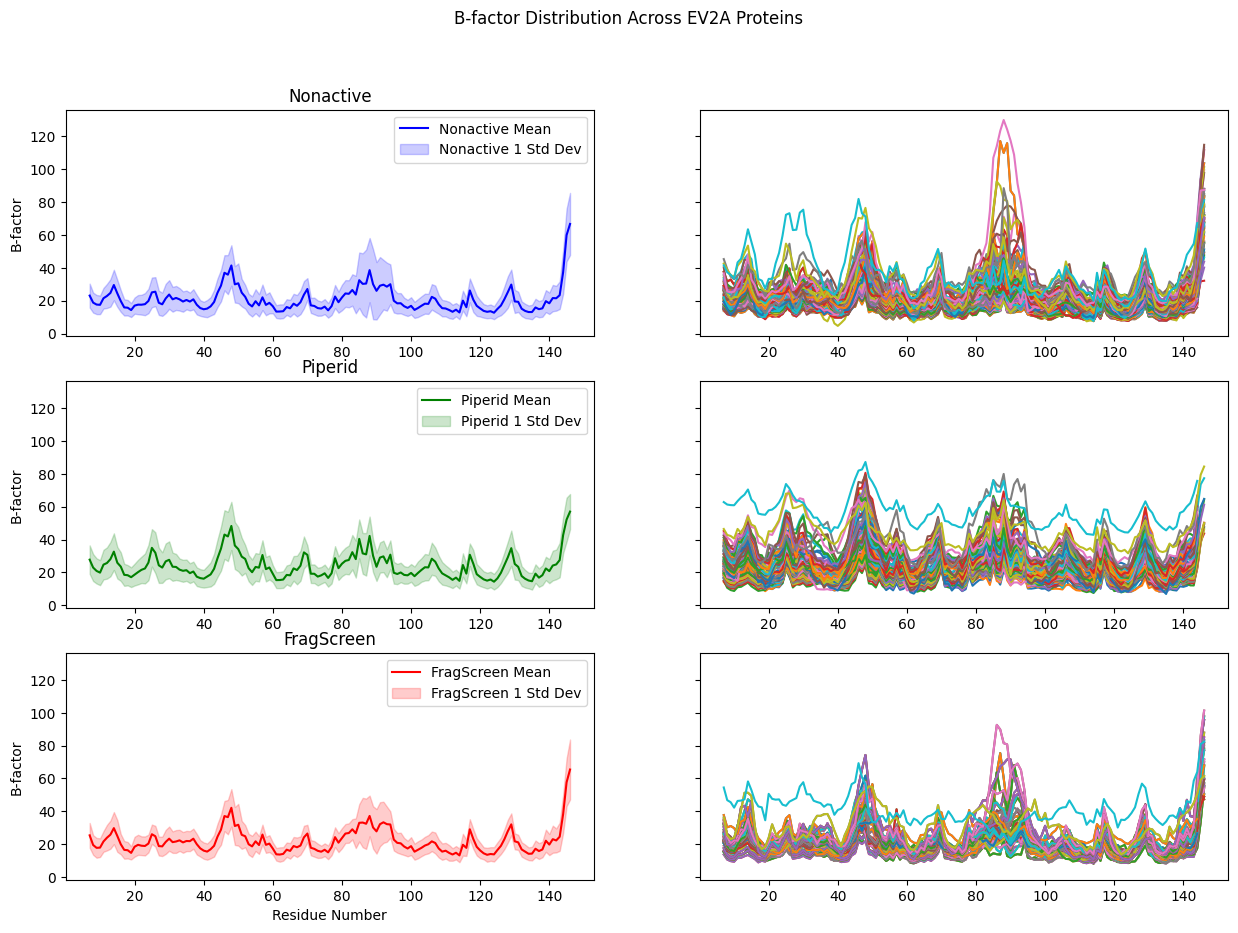

In [26]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
fig, ax  = plt.subplots( 3, 2 ,  figsize=(15,10), sharey=True)
for i, (dataset_name, color) in enumerate(zip(["Nonactive", "Piperid","FragScreen",  ], ['blue', 'green', 'red'])):
    
    bfactor_mean = all_bfactor_dict[ dataset_name ]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["std"]
    ax[i,0].plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
             , color= color)
    ax[i,0].fill_between( residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )
    ax[-1, 0].set_xlabel("Residue Number")
    ax[i, 0].set_ylabel("B-factor")
    ax[i, 0].set_title(f"{dataset_name}")
    ax[i, 0].legend()

    b_factor_vals = sorted_bfactor_dicts[dataset_name]["values"]
    start, end =  b_factor_vals.shape[0] - (b_factor_vals.shape[0]) ,  b_factor_vals.shape[0]-1, 
    num_datapoints = 100
    select_values = np.linspace( start, end, num_datapoints, dtype=np.int64 )
    for values in b_factor_vals[ select_values]:
        ax[i, 1].plot( residues_num, values)
    # print(select_values)
    # break

# plt.grid()
plt.suptitle("B-factor Distribution Across EV2A Proteins")
plt.show()

- ## Normalize B-factors

In [27]:
# Normalise b-factors plots
norm_bfactor_dicts = dict()
for dataset_name in ["Nonactive", "Piperid","FragScreen",  ]:
    norm_bfactor_dicts[dataset_name] = dict()
# print(sorted_bfactor_dicts["Nonactive"]["values"].shape )
# print( np.mean( sorted_bfactor_dicts["Nonactive"]["values"], axis = 1).shape )
    num_datasets = sorted_bfactor_dicts[dataset_name]["values"].shape[0]
    norm_bfactor_dicts[dataset_name]["values"] = ( sorted_bfactor_dicts[dataset_name]["values"] - np.nanmean( sorted_bfactor_dicts[dataset_name]["values"], axis = 1).reshape( (num_datasets,1) ) ) / np.nanstd( sorted_bfactor_dicts[dataset_name]["values"], axis = 1).reshape( (num_datasets,1) ) 
    norm_bfactor_dicts[dataset_name]["mean"] = np.nanmean( norm_bfactor_dicts[dataset_name]["values"], axis = 0)
    norm_bfactor_dicts[dataset_name]["std"] = np.nanstd( norm_bfactor_dicts[dataset_name]["values"], axis = 0)
    print("{}: {}".format(dataset_name, norm_bfactor_dicts[dataset_name]["values"].shape))

Nonactive: (99, 140)
Piperid: (454, 140)
FragScreen: (42, 140)


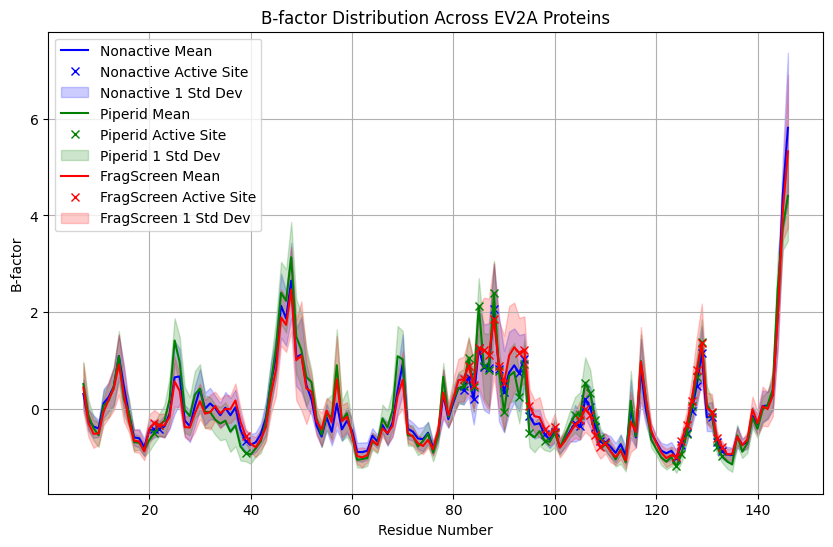

In [28]:
# Plot b-factors Distribution
active_site_res_idxs  = np.array( [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126])
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
plt.figure(figsize=(10,6))
for dataset_name, color in zip(["Nonactive", "Piperid","FragScreen",  ][:], ['blue', 'green', 'red'][:]):
    bfactor_mean = norm_bfactor_dicts[ dataset_name ]["mean"]
    bfactor_std = norm_bfactor_dicts[ dataset_name ]["std"]
    plt.plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
             , color= color)

    plt.plot( active_site_res_idxs + 7, bfactor_mean[active_site_res_idxs],"x",   label="{} Active Site".format(dataset_name)
            , color= color)

    plt.fill_between(residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name)  )
plt.xlabel("Residue Number")
plt.ylabel("B-factor")
plt.title("B-factor Distribution Across EV2A Proteins")
plt.legend()
plt.grid()
plt.show()

# Plot Separetly

# fig, ax  = plt.subplots( 3, 1 ,  figsize=(20,30), sharey=True)
# for i, (dataset_name, color) in enumerate(zip(["Nonactive", "Piperid","FragScreen",  ], ['blue', 'green', 'red'])):
    
#     bfactor_mean = norm_bfactor_dicts[ dataset_name ]["mean"]
#     bfactor_std = norm_bfactor_dicts[ dataset_name ]["std"]
#     ax[i].plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
#              , color= color)
#     ax[i].plot( active_site_res_idxs + 7, bfactor_mean[active_site_res_idxs],"x",   label="{} Active Site".format(dataset_name)
#             , color= color)

#     ax[i].fill_between( residues_num, bfactor_mean - bfactor_std,
#                       bfactor_mean + bfactor_std, color=color, alpha=0.2,
#                     label="{} 1 Std Dev".format(dataset_name) )
#     ax[i].set_xlabel("Residue Number")
#     ax[i].set_ylabel("B-factor")
#     ax[i].set_title("B-factor Distribution Across EV2A Proteins")
#     ax[i].legend()

#     b_factor_vals = norm_bfactor_dicts[dataset_name]["values"]
#     start, end =  b_factor_vals.shape[0] - (b_factor_vals.shape[0]) ,  b_factor_vals.shape[0]-1, 
#     num_datapoints = b_factor_vals.shape[0]
#     select_values = np.linspace( start, end, num_datapoints, dtype=np.int64 )
#     # for values in b_factor_vals[ select_values]:
#     #     ax[i, 1].plot( residues_num, values)
#     # print(select_values)
#     # break

# # plt.grid()
# plt.show()

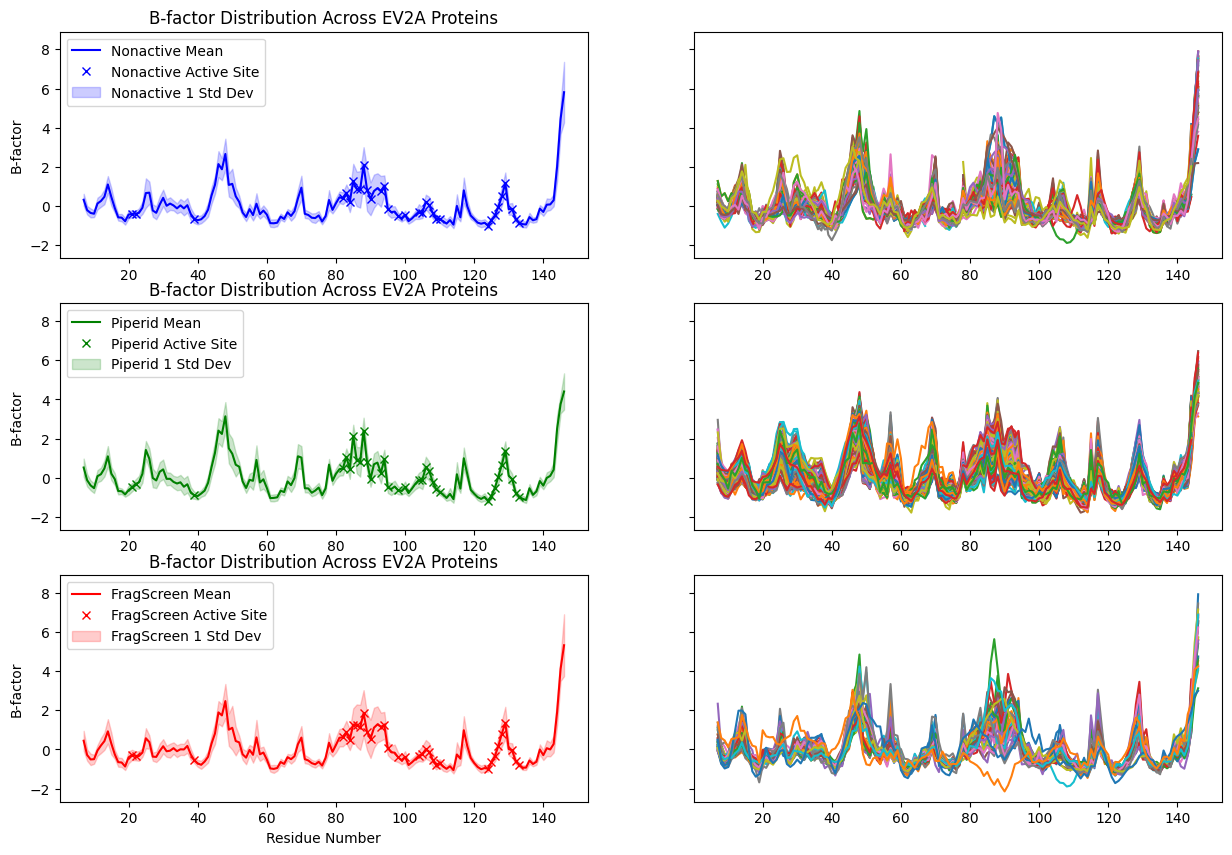

In [29]:
# Plot b-factors Distribution
active_site_res_idxs  = np.array( [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126])
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
fig, ax  = plt.subplots( 3, 2 ,  figsize=(15,10), sharey=True)
for i, (dataset_name, color) in enumerate(zip(["Nonactive", "Piperid","FragScreen",  ], ['blue', 'green', 'red'])):
    
    bfactor_mean = norm_bfactor_dicts[ dataset_name ]["mean"]
    bfactor_std = norm_bfactor_dicts[ dataset_name ]["std"]
    ax[i,0].plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
             , color= color)
    ax[i,0].plot( active_site_res_idxs + 7, bfactor_mean[active_site_res_idxs],"x",   label="{} Active Site".format(dataset_name)
            , color= color)

    ax[i,0].fill_between( residues_num, bfactor_mean - bfactor_std,
                      bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )
    ax[-1, 0].set_xlabel("Residue Number")
    ax[i, 0].set_ylabel("B-factor")
    ax[i, 0].set_title("B-factor Distribution Across EV2A Proteins")
    ax[i, 0].legend()

    b_factor_vals = norm_bfactor_dicts[dataset_name]["values"]
    start, end =  b_factor_vals.shape[0] - (b_factor_vals.shape[0]) ,  b_factor_vals.shape[0]-1, 
    num_datapoints = b_factor_vals.shape[0]
    select_values = np.linspace( start, end, num_datapoints, dtype=np.int64 )
    for values in b_factor_vals[ select_values]:
        ax[i, 1].plot( residues_num, values)
    # print(select_values)
    # break

# plt.grid()
plt.show()

(33,)


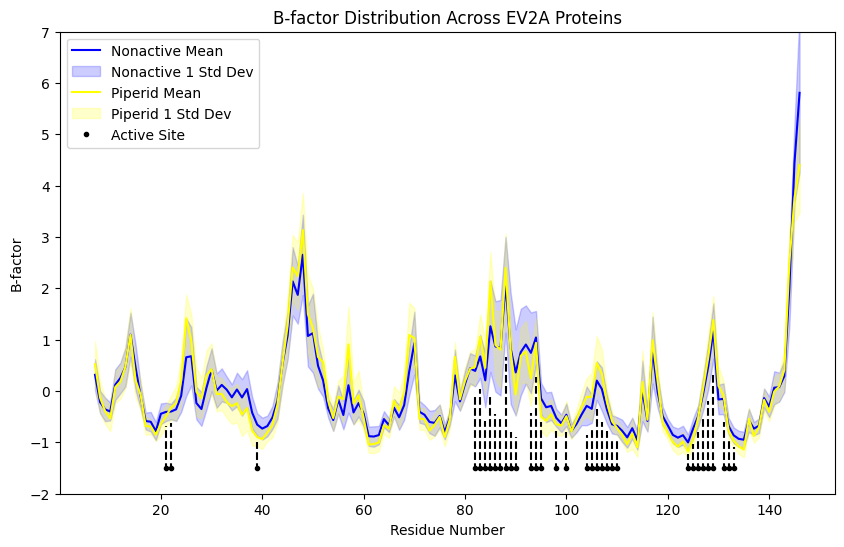

In [30]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
active_site_res_idxs  = np.array( [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126])
residues_num = np.arange(7, len(ref_seq)+7)
fig, ax  = plt.subplots(1 ,  figsize=(10,6), sharey=True)
for dataset_name, color in zip(["Nonactive", "Piperid"], ['blue', 'yellow']):
    
    bfactor_mean = norm_bfactor_dicts[ dataset_name ]["mean"]
    bfactor_std = norm_bfactor_dicts[ dataset_name ]["std"]
    ax.plot( residues_num, bfactor_mean, label="{} Mean".format(dataset_name)
            , color= color)


    ax.fill_between( residues_num, bfactor_mean - bfactor_std,
                    bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(dataset_name) )



ax.plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-1.5,".",   label="Active Site".format(dataset_name)
        , color= "black")
print
x = active_site_res_idxs + 7
y_min = np.ones_like(active_site_res_idxs )*0.05 # np.ones_like(active_site_res_idxs )*-1.5 # np.ones_like(active_site_res_idxs )*-1
print(y_min.shape)
mean, std = norm_bfactor_dicts[ "Nonactive" ]["mean"][active_site_res_idxs], norm_bfactor_dicts[ "Nonactive" ]["std"][active_site_res_idxs]
y_max =   ( ( mean - std*1.5)   + 2)/(7 + 2)

for xi, ymin_i, ymax_i in zip(x, y_min, y_max):
    ax.axvline(x=xi, ymin=ymin_i, ymax=ymax_i, ls="--", color="black")


ax.set_ylim(-2, 7)
ax.set_xlabel("Residue Number")
ax.set_ylabel("B-factor")
ax.set_title("B-factor Distribution Across EV2A Proteins")
ax.legend()

plt.show()

loading dataset:  Nonactive


NameError: name 'step' is not defined

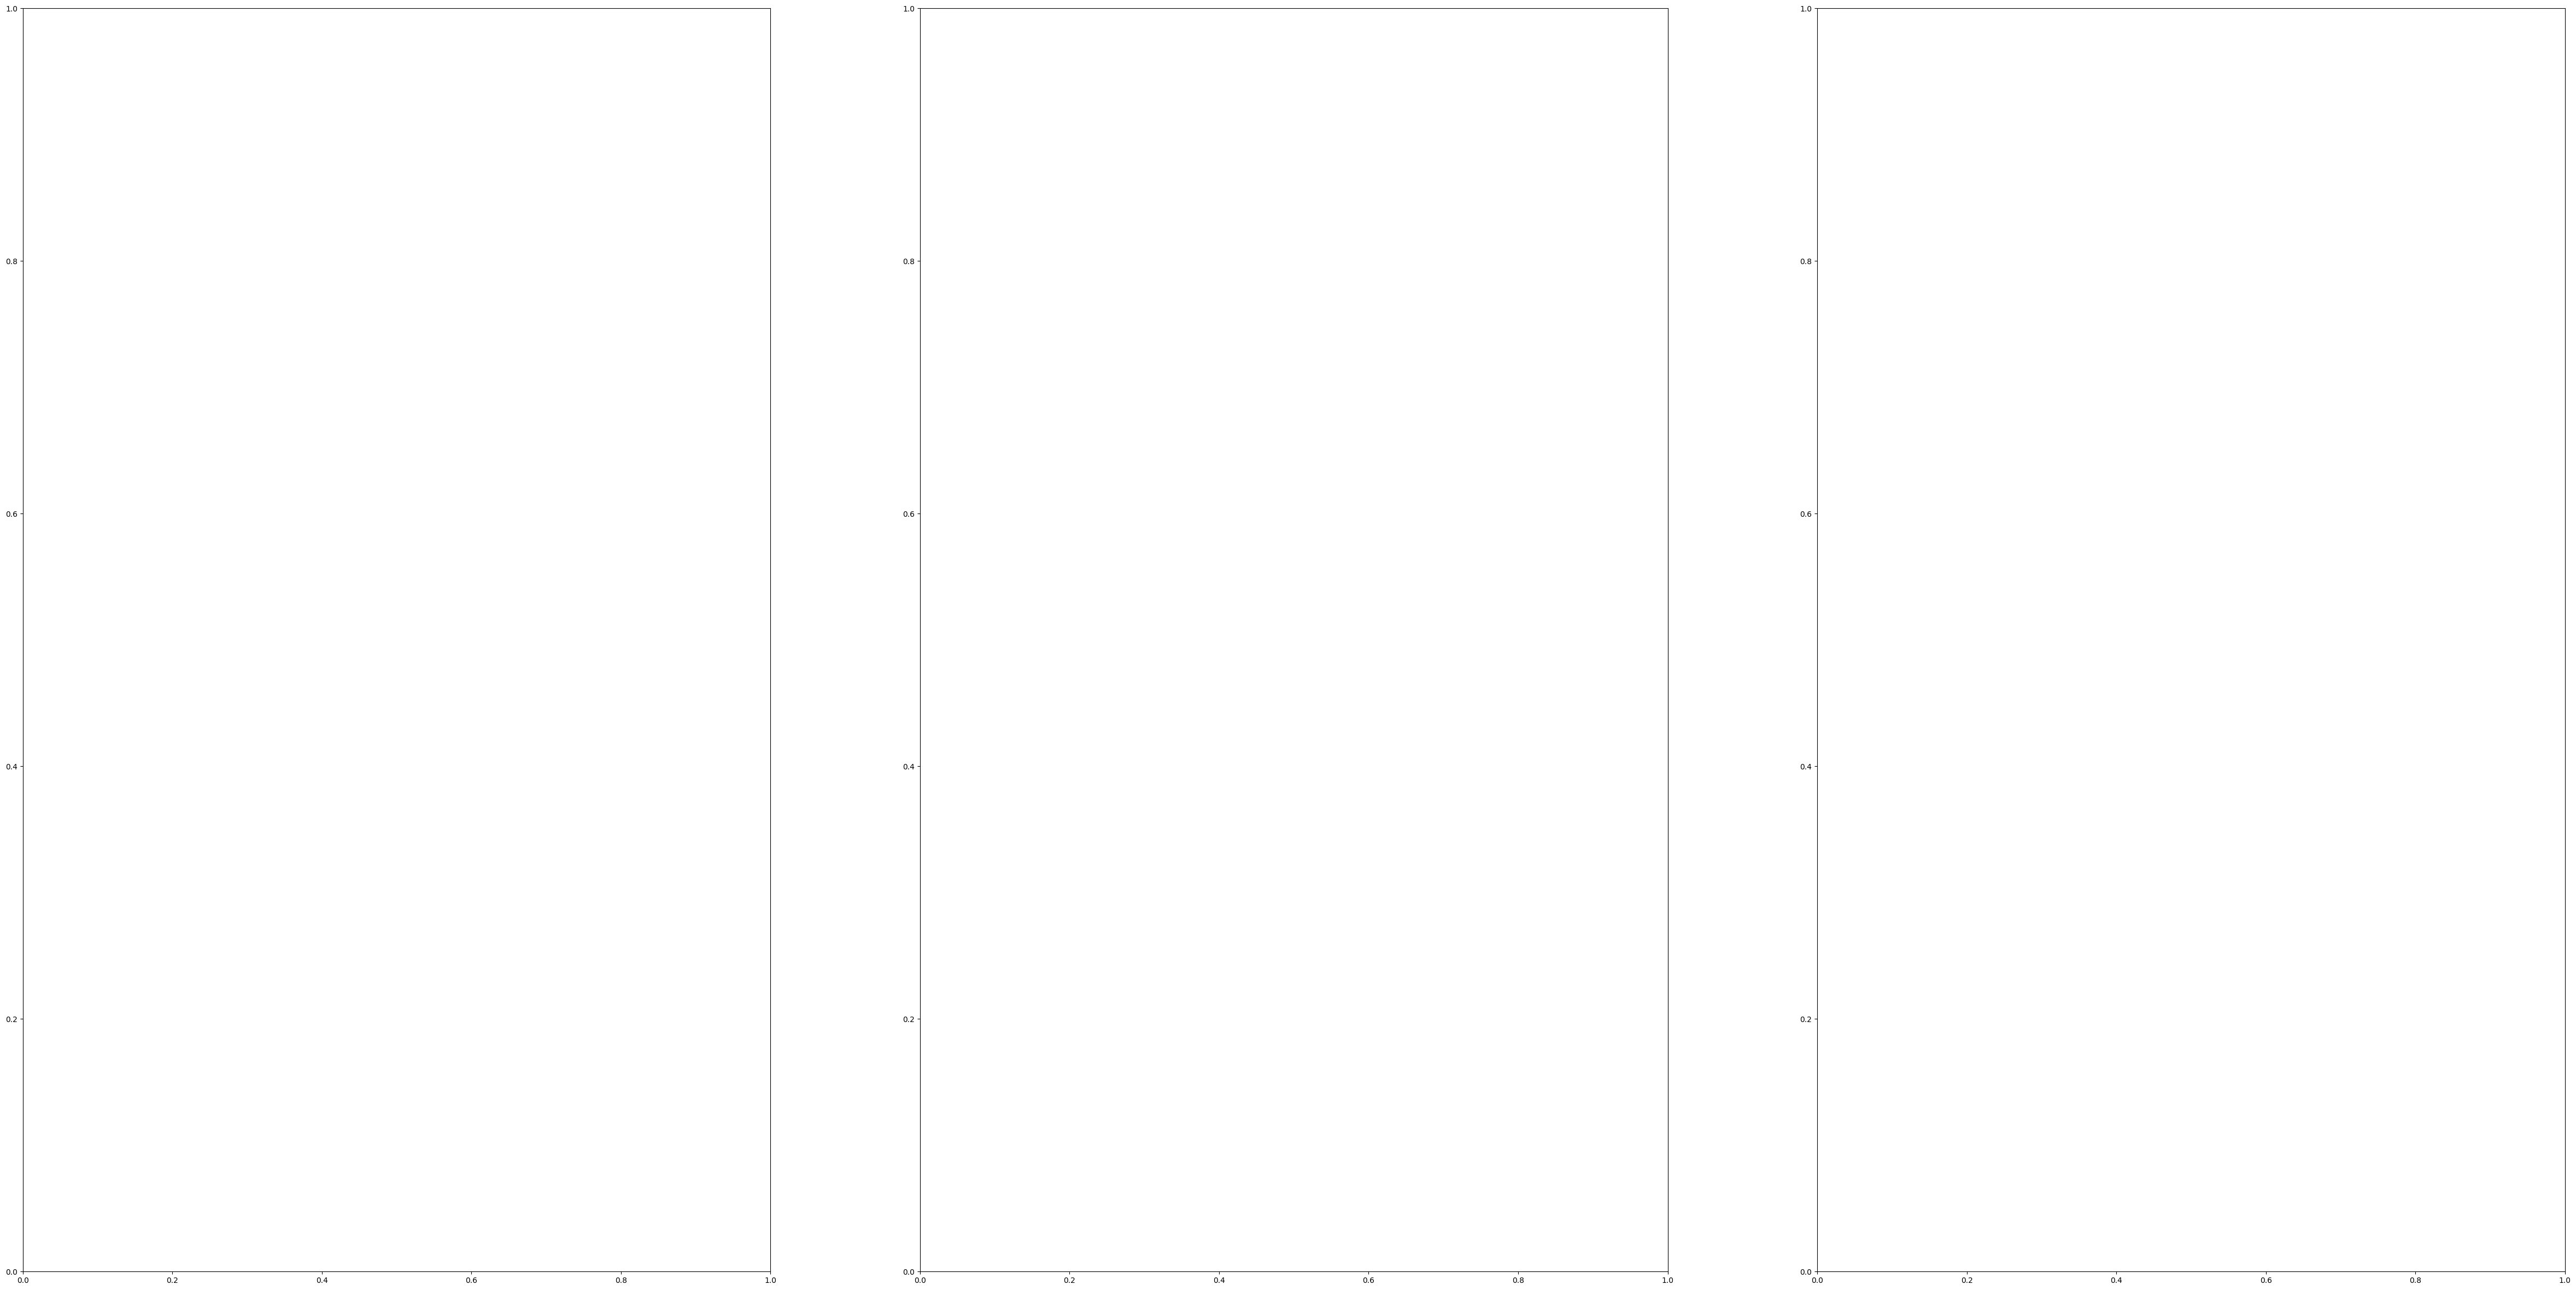

In [31]:
import matplotlib.pyplot as plt
residues_num = np.arange(7, len(ref_seq)+7)
fig, ax  = plt.subplots( 1, 3 ,  figsize=(60,30), sharey=False)
for i, dataset_name in enumerate(["Nonactive", "Piperid","FragScreen",]):
    
    print( "loading dataset: ", dataset_name)
    b_factor_vals = norm_bfactor_dicts[dataset_name]["values"]
    start, end, = step*window ,   (step+1)*window 
    select_values = np.arange( start, end, dtype=np.int64 )
    
    if len(b_factor_vals) < end:
        continue
    count = 0
    for idx, values in enumerate(b_factor_vals[ select_values]):
        values = values + 5*count
        if len(values) != len(residues_num):
            print("Length mismatch: values length = {}, residues_num length = {}".format(len(values), len(residues_num)))
        residues_num = np.arange(7, len(values)+7)
        ax[i ].plot( residues_num, values, label = idx + (step*window) )
        count += 1
    ax[i].set_xlabel("Residue Number")
    ax[i].set_ylabel("B-factor")
    ax[i].set_title("B-factor Distribution Across EV2A Proteins for {}".format( dataset_name))
    ax[i].legend()

    # print(select_values)
    # break

# plt.grid()
plt.show()
step +=1 

# Looking at All VS Ground VS Bound Only

- Ground State and All Proteins

In [ ]:
# Code from 02.1 - filterfraglis_groundprot

from xaidar.data.molecModels import ( flatten_pdb, get_pdb_stats, loadPDB,
                                     sele_pdb, sele_AA, sele_closest_Chain, sele_Lig,
                                      get_res_CoM, sele_closest_res, structAlign,get_res_bfactors)

rootdir = Path("../../../..").resolve()
rootProjDir = rootdir / "data/ev2a/fragalysis"
rawdataDir = rootProjDir / "01-concatDir/aligned_files"
refProjDir = rootProjDir / "02-chemofint/reference"

# Active Site Coordinates
ref_pdb = gemmi.read_pdb( refProjDir.joinpath("A0926a.pdb").__str__() )

ref_lig = sele_pdb( ref_pdb, sele_Lig)
ref_lig_CoM = get_res_CoM( flatten_pdb( ref_lig,  "residue") )

ref_prot = sele_pdb( sele_pdb( ref_pdb, sele_AA), sele_closest_Chain, ref_lig_CoM )
ref_prot[0]["B"].name = "A"
ref_prot_CoM = np.array( ref_prot[0].calculate_center_of_mass().tolist()) 

# Protein Closest to Reference Protein CoM
database = dict()
for dataset in rawdataDir.iterdir():
    if dataset.is_dir():
        dataset_name = dataset.name
        database[dataset_name] = {"protein":None, "ligand": None, "waters": None, "rmsd": None}
        
        dataset_pdb = gemmi.read_pdb( dataset.joinpath("{}.pdb".format( dataset_name ) ).__str__() )
        
        dataset_prot = sele_pdb( sele_pdb(dataset_pdb, sele_AA), sele_closest_Chain, ref_prot_CoM) 
        dataset_prot_CoM = np.array( dataset_prot[0].calculate_center_of_mass().tolist() )
        database[dataset_name]["protein"] = dataset_prot

        dataset_lig = sele_pdb( sele_pdb( dataset_pdb, sele_Lig), sele_closest_res, dataset_prot_CoM)
        database[dataset_name]["ligand"] = dataset_lig

        rmsd = structAlign( ref_prot, dataset_prot).calc_rmsd().rmsd
        database[dataset_name]["rmsd"] = round( rmsd, 3) 
        if rmsd > 5:
            transform = structAlign( ref_prot, dataset_prot).calc_transform().transform
            aligned_prot = structAlign( None, dataset_prot).apply_transform( transform).aligned_prot
            aligned_lig = structAlign( None, dataset_lig).apply_transform( transform).aligned_prot
            new_rmsd = structAlign( ref_prot, aligned_prot).calc_rmsd().rmsd
            database[dataset_name]["protein"] = aligned_prot
            database[dataset_name]["ligand"] = aligned_lig
            database[dataset_name]["rmsd"] = round( new_rmsd, 3) 

all_prots, *_ = zip(   *[ tuple( dataset.values()) for dataset in database.values() ] )
print( "Total datasets loaded: ", len(all_prots) )

# Filter datasets with only one conformer
oneConformer_dataset_names =  [ dataset for dataset in database.keys() if [v[:-1] for v in database.keys()].count(dataset[:-1]) == 1]
oneConformer_datasets = { dataset_name : content for dataset_name, content in database.items() if dataset_name in oneConformer_dataset_names }
print("Datasets with one conformer: ", len(oneConformer_datasets))

oneConf_prots, oneConf_ligs, _, _ = zip(   *[ tuple( dataset.values()) for dataset in oneConformer_datasets.values() ] )

lig_distances = [ gemmi.Position( *get_res_CoM( flatten_pdb(lig, "residue")).flatten() 
                ).dist(gemmi.Position( *ref_lig_CoM.flatten() )) for lig in oneConf_ligs]

nonactivesite_ligs = [ idx for idx, dist in enumerate(lig_distances) if dist > 15 ]
nonactivesite_prots = [ oneConf_prots[idx] for idx in nonactivesite_ligs ]
print("Non Active Site Proteins: ", len(nonactivesite_prots))

Total datasets loaded:  686
Datasets with one conformer:  391
Non Active Site Proteins:  35


- Piperidine Series Proteins

In [ ]:
piperidine_dir = rootProjDir / "02-chemofint/piperid"
piperidine_datasets = dict()
for dataset in piperidine_dir.iterdir():
    if dataset.is_dir():
        dataset_name = dataset.name
        piperidine_datasets[dataset_name] = {"protein":None, "ligand": None, "waters": None, "rmsd": None}
        
        dataset_pdb = gemmi.read_pdb( dataset.joinpath("{}.pdb".format( dataset_name ) ).__str__() )
        
        dataset_prot = sele_pdb( sele_pdb(dataset_pdb, sele_AA), sele_closest_Chain, ref_prot_CoM) 
        dataset_prot_CoM = np.array( dataset_prot[0].calculate_center_of_mass().tolist() )
        piperidine_datasets[dataset_name]["protein"] = dataset_prot

        dataset_lig = sele_pdb( sele_pdb( dataset_pdb, sele_Lig), sele_closest_res, dataset_prot_CoM)
        piperidine_datasets[dataset_name]["ligand"] = dataset_lig

        rmsd = structAlign( ref_prot, dataset_prot).calc_rmsd().rmsd
        piperidine_datasets[dataset_name]["rmsd"] = round( rmsd, 3) 
        if rmsd > 5:
            transform = structAlign( ref_prot, dataset_prot).calc_transform().transform
            aligned_prot = structAlign( None, dataset_prot).apply_transform( transform).aligned_prot
            aligned_lig = structAlign( None, dataset_lig).apply_transform( transform).aligned_prot
            new_rmsd = structAlign( ref_prot, aligned_prot).calc_rmsd().rmsd
            piperidine_datasets[dataset_name]["protein"] = aligned_prot
            piperidine_datasets[dataset_name]["ligand"] = aligned_lig
            piperidine_datasets[dataset_name]["rmsd"] = round( new_rmsd, 3) 

# Filter datasets with only one conformer
pip_oneConformer_dataset_names =  [ dataset for dataset in piperidine_datasets.keys() if [v[:-1] for v in piperidine_datasets.keys()].count(dataset[:-1]) == 1]
pip_oneConformer_datasets = { dataset_name : content for dataset_name, content in piperidine_datasets.items() if dataset_name in pip_oneConformer_dataset_names }
# pip_oneConf_prots, *_ = zip( *[ tuple( dataset.values() ) for  dataset in pip_oneConformer_datasets.values() ] )
pip_oneConf_names, pip_oneConf_prots, *_ = zip(   *[ tuple( [dataset_name] ) + tuple( dataset.values()) for dataset_name, dataset in pip_oneConformer_datasets.items() ] )
# print(pip_oneConf_prots)
print(pip_oneConf_names.__len__())

242


In [ ]:
from xaidar.data.molecModels import model_seqAlign
prot_names = [ "All", "Nonactive", "Piperid" ]
aa_distrib_dict = dict()
for prot_lst, prot_name in zip( [ all_prots, nonactivesite_prots,pip_oneConf_prots], prot_names):
    aa_distrib_dict[ prot_name ] = dict()

    res_seqs = [ model_seqAlign(ref_prot, prot).align().map_matching_res(gaps=True).matched_res["Query"]
                        for prot in prot_lst ]
    aa_distrib_dict[ prot_name ]["res_seq"] = res_seqs

# print( set( len(res_seq ) for res_seq in all_prots_res_seqs)) 
# print(  [ True if None in res_seq else False for res_seq in all_prots_res_seqs].count(False)) 

# aa_distrib_lst = [ all_prots_res_seqs, nonactivesite_prots,pip_oneConf_prots]
# prot_names = [ "All", "Nonactive", "Piperid" ]
# aa_distrib_dict = {}

for name, dataset in aa_distrib_dict.items():
    print("Calculating b-factors for {} dataset".format(name))

    res_seqs = dataset["res_seq"]
    all_seqs_bfactors = []
    for res_seq in res_seqs: all_seqs_bfactors.append( get_res_bfactors( res_seq, sign_fig = 5) )
    all_seqs_bfactors = [ [ value if value != None else np.nan for value in seq_bfactors ]
                                            for seq_bfactors in all_seqs_bfactors ]
    aa_distrib_dict[name]["b-factors"] = all_seqs_bfactors


Calculating b-factors for All dataset
Calculating b-factors for Nonactive dataset
Calculating b-factors for Piperid dataset


In [ ]:
all_bfactor_dict = {}

for dataset_name in aa_distrib_dict.keys():
    all_bfactor_dict[ dataset_name ] = dict()
    bfactor_dict = {}
    bfactor_dict["values"] = np.array( aa_distrib_dict[dataset_name]["b-factors"] )
    bfactor_dict["mean"] = np.nanmean( bfactor_dict["values"], axis=0)
    bfactor_dict["std"] = np.nanstd( bfactor_dict["values"], axis=0)
    all_bfactor_dict[ dataset_name ]["Raw Values"] = bfactor_dict

# bfactor_values = np.array( all_seqs_bfactors )
# bfactor_mean = np.nanmean(bfactor_values, axis=0)
# bfactor_std = np.nanstd(bfactor_values, axis=0)
for name in prot_names:
    print( f"{name} Bfactor values array shape: ", all_bfactor_dict[name]["Raw Values"]["values"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor means array shape: ", all_bfactor_dict[name]["Raw Values"]["mean"].shape )
print()
for name in prot_names:
    print( f"{name} Bfactor std array shape: ", all_bfactor_dict[name]["Raw Values"]["std"].shape )

All Bfactor values array shape:  (686, 140)
Nonactive Bfactor values array shape:  (35, 140)
Piperid Bfactor values array shape:  (242, 140)

All Bfactor means array shape:  (140,)
Nonactive Bfactor means array shape:  (140,)
Piperid Bfactor means array shape:  (140,)

All Bfactor std array shape:  (140,)
Nonactive Bfactor std array shape:  (140,)
Piperid Bfactor std array shape:  (140,)


In [ ]:
# Normalise b-factors plots

for dataset_name in all_bfactor_dict.keys():
    all_bfactor_dict[ dataset_name ]["Normalized Values"] = dict()

    num_datasets = all_bfactor_dict[dataset_name]["Raw Values"]["values"].shape[0]
    mean = np.nanmean( all_bfactor_dict[dataset_name]["Raw Values"]["values"], axis = 1).reshape( (num_datasets,1) )
    std = np.nanstd( all_bfactor_dict[dataset_name]["Raw Values"]["values"], axis = 1).reshape( (num_datasets,1) )

    all_bfactor_dict[dataset_name]["Normalized Values"]["values"] = ( (all_bfactor_dict[dataset_name]["Raw Values"]["values"] - mean) / std ) 
    all_bfactor_dict[dataset_name]["Normalized Values"]["mean"] = np.nanmean( all_bfactor_dict[dataset_name]["Normalized Values"]["values"], axis = 0)
    all_bfactor_dict[dataset_name]["Normalized Values"]["std"] = np.nanstd( all_bfactor_dict[dataset_name]["Normalized Values"]["values"], axis = 0)
    print("{}: {}".format(dataset_name, all_bfactor_dict[dataset_name]["Normalized Values"]["values"].shape))

All: (686, 140)
Nonactive: (35, 140)
Piperid: (242, 140)


Ground State Only

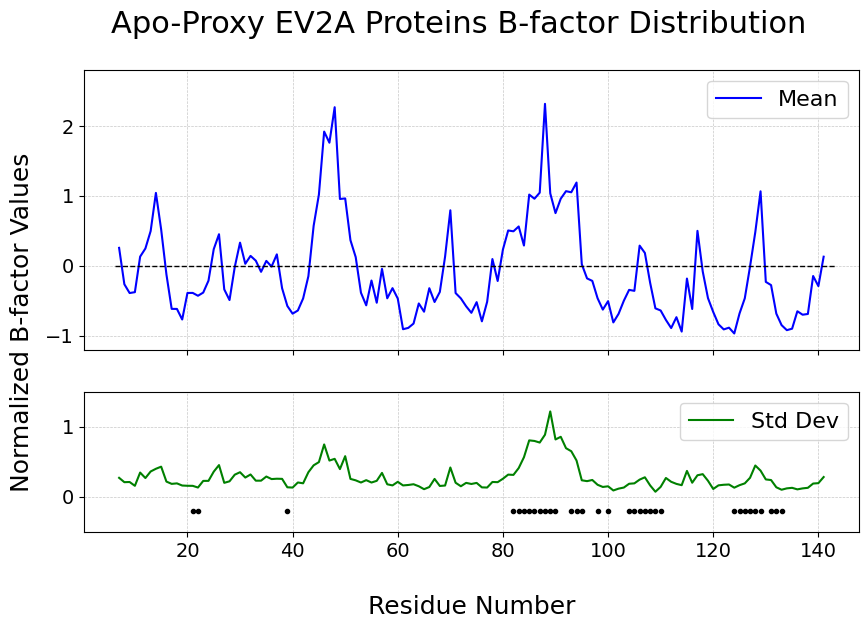

In [ ]:
# Plot b-factors Distribution
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
import matplotlib.pyplot as plt
height_ratios = [2, 1]
fig, ax  = plt.subplots(2 ,  figsize=(10,6), sharex = True, sharey= False, gridspec_kw={'height_ratios': height_ratios}) #gridspec_kw={'width_ratios': width_ratios})
residues_num = np.arange(7, len(ref_seq)+7)
ax[0].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["mean"][:-5], color= 'blue', label = "Mean")
ax[0].set_ylim(-1.2, 2.8)
ax[0].tick_params( labelsize=axis_numb_size)
# Set horizontal line at y=0 starting from x=7 to the end of residues_num
ax[0].axhline( y=0, color='black', linestyle='--', linewidth=1, xmin=0.04, xmax=0.97)
# Set a grid
ax[0].grid( linestyle='--', linewidth=0.5, alpha=0.7)
ax[1].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["std"][:-5], color = "green", label = "Std Dev")
ax[1].plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-0.2,".",  # label="Active Site",
        color= "black")
ax[1].set_ylim(-0.5, 1.5)
for i in range(2):
    ax[i].legend( fontsize=leg_size)
ax[1].set_xlabel("Residue Number", labelpad=25, fontsize=axis_size)
ax[1].set_ylabel("Normalized B-factor Values", y = 1.5, rotation=90, labelpad=20, fontsize=axis_size)
ax[1].tick_params( labelsize=axis_numb_size)
ax[1].grid( linestyle='--', linewidth=0.5, alpha=0.7)
# ax[0].set_title("Mean B-factor Distribution For Apo EV2A Proteins")
# ax[1].set_title("Standard Deviation B-factor Distribution For Apo EV2A Proteins")

plt.suptitle("Apo-Proxy EV2A Proteins B-factor Distribution", fontsize=title_size + 2)
plt.show()

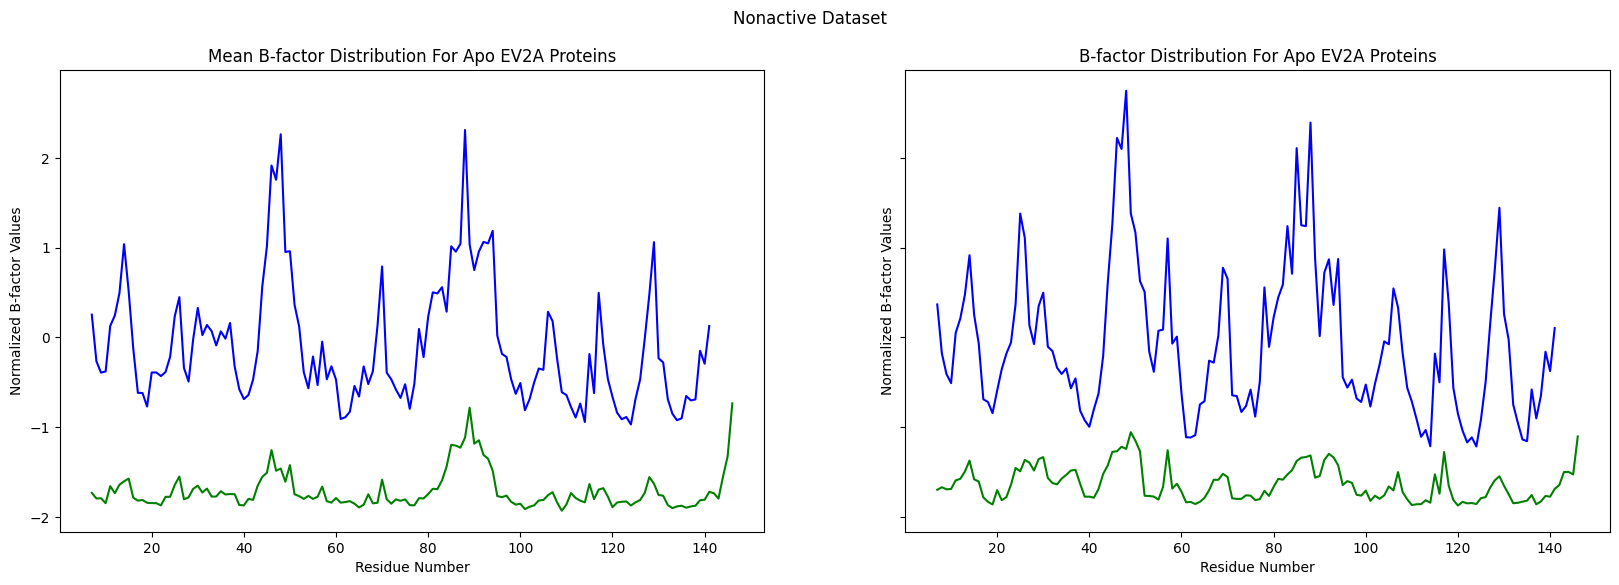

In [ ]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
fig, ax  = plt.subplots(1, 2 ,  figsize=(20,6), sharex = True, sharey= True)
residues_num = np.arange(7, len(ref_seq)+7)
ax[0].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["mean"][:-5], color= 'blue')
ax[0].plot( residues_num, all_bfactor_dict["Nonactive"]["Normalized Values"]["std"] -2, color = "green")
ax[1].plot( residues_num[:-5], all_bfactor_dict["Piperid"]["Normalized Values"]["mean"][:-5], color= 'blue')
ax[1].plot( residues_num, all_bfactor_dict["Piperid"]["Normalized Values"]["std"] -2, color = "green")
for i in range(2):
    ax[i].set_xlabel("Residue Number")
    ax[i].set_ylabel("Normalized B-factor Values")
ax[0].set_title("Mean B-factor Distribution For Apo EV2A Proteins")
ax[1].set_title("B-factor Distribution For Apo EV2A Proteins")
plt.suptitle("Nonactive Dataset")
plt.show()

(33,)


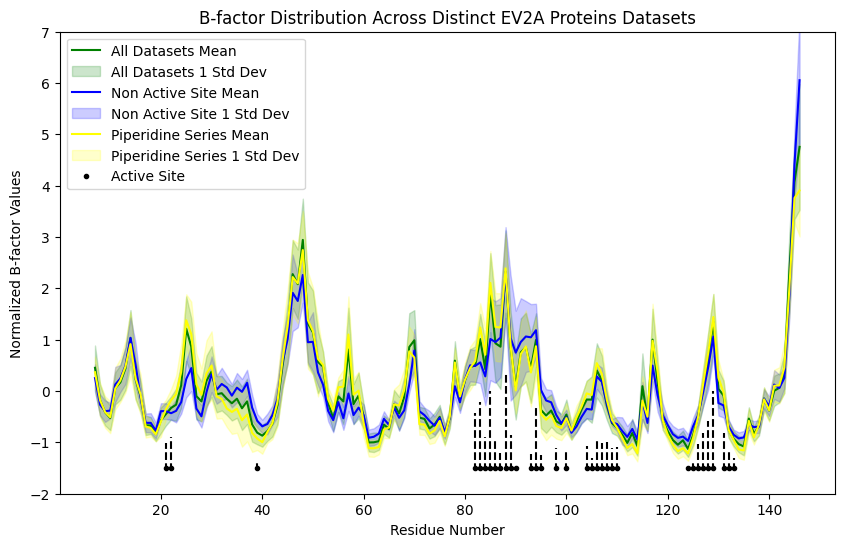

In [ ]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
active_site_res_idxs  = np.array( [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126])
residues_num = np.arange(7, len(flatten_pdb( ref_prot, "residue"))+7)
fig, ax  = plt.subplots(1 ,  figsize=(10,6), sharey=True)
for dataset_name, label, color in zip(all_bfactor_dict.keys(),
                                      ["All Datasets", "Non Active Site", "Piperidine Series"], 
                                      ["green", 'blue', 'yellow']):
    
    bfactor_mean = all_bfactor_dict[ dataset_name ]["Normalized Values"]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["Normalized Values"]["std"]
    ax.plot( residues_num, bfactor_mean, label="{} Mean".format(label)
            , color= color)


    ax.fill_between( residues_num, bfactor_mean - bfactor_std,
                    bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(label) )



ax.plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-1.5,".",   label="Active Site".format(label)
        , color= "black")
print
x = active_site_res_idxs + 7
y_min = np.ones_like(active_site_res_idxs )*0.05 # np.ones_like(active_site_res_idxs )*-1.5 # np.ones_like(active_site_res_idxs )*-1
print(y_min.shape)
mean, std = all_bfactor_dict[ "All" ]["Normalized Values"]["mean"][active_site_res_idxs], all_bfactor_dict[ "All" ]["Normalized Values"]["std"][active_site_res_idxs]
y_max =   ( ( mean - std*2.5)   + 2)/(7 + 2)

for xi, ymin_i, ymax_i in zip(x, y_min, y_max):
    ax.axvline(x=xi, ymin=ymin_i, ymax=ymax_i, ls="--", color="black")


ax.set_ylim(-2, 7)
ax.set_xlabel("Residue Number")
ax.set_ylabel("Normalized B-factor Values")
ax.set_title("B-factor Distribution Across Distinct EV2A Proteins Datasets")
ax.legend()

plt.savefig("normBfactorDist.png", dpi=600)
plt.show()


All Datasets sum dist shape:  [ 4.13002965e-14 -5.68434189e-14  2.04281037e-14 -4.44089210e-14
 -1.10134124e-13]
Non Active Site sum dist shape:  [ 4.13002965e-14 -9.76996262e-15  1.77635684e-14 -8.77076189e-14
  8.30446822e-14]
Piperidine Series sum dist shape:  [-5.68434189e-14 -4.44089210e-14 -4.26325641e-14 -7.54951657e-15
  1.95399252e-14]


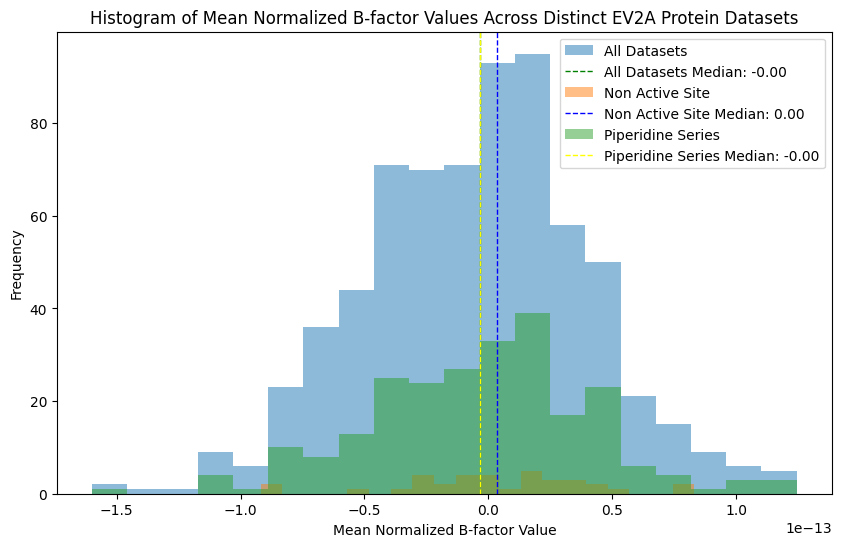

In [ ]:
plt.figure(figsize=(10,6))
for dataset_name, label, color, alpha in zip(all_bfactor_dict.keys(),
                                      ["All Datasets", "Non Active Site", "Piperidine Series"], 
                                      ["green", 'blue', 'yellow'],
                                      [0.2, 0.5, 0.8]):
    
    sum_dist = np.nansum(all_bfactor_dict[ dataset_name ]["Normalized Values"]["values"], axis = 1)
    median_dist = np.median(sum_dist)
    print( f"{label} sum dist shape: ", sum_dist[:5])
    plt.hist( sum_dist, bins= 20 , density=False, alpha=0.5, label=label)
    plt.axvline( median_dist, color=color, linestyle='dashed', linewidth=1,
                label="{} Median: {:.2f}".format(label, median_dist) )
plt.xlabel("Mean Normalized B-factor Value")
plt.ylabel("Frequency")
plt.title("Histogram of Mean Normalized B-factor Values Across Distinct EV2A Protein Datasets")
plt.legend()
plt.show()
# print(mean_dist.shape )


#### Looking at the Difference

In [ ]:
print( all_bfactor_dict.keys() )

dict_keys(['All', 'Nonactive', 'Piperid'])


In [ ]:
mean_diff = all_bfactor_dict[ "Piperid" ]["Normalized Values"]["mean"] - all_bfactor_dict[ "Nonactive" ]["Normalized Values"]["mean"]
print( mean_diff.shape)
print( len(mean_diff))
print( mean_diff.tolist())

(140,)
140
[0.11361103653581894, 0.08832099930741283, -0.01655302228996247, -0.12986213802153584, -0.07786686262036832, -0.03454683572803652, -0.018523287161479718, -0.12278591880883749, -0.2633052316668376, 0.057821793308276526, -0.07109203549937826, -0.10029168472548211, -0.07363529223826737, -0.20145208742484805, 0.03774858746849613, 0.2494730284495231, 0.32865850723516854, 0.5863551345838967, 1.1441205093756248, 0.6593967240556001, 0.4737349025873938, 0.41707626589170643, 0.3668919542656286, 0.17023491681003688, -0.1293884712358614, -0.2909121604699876, -0.4088491726814917, -0.31802117363091875, -0.4117179434070353, -0.5532166290718077, -0.6171987691603615, -0.49156300827925203, -0.34629845645234814, -0.3085292033231717, -0.15749910868446337, -0.1563008297999559, -0.057240807285628414, 0.039831510890703026, 0.24801749023636965, 0.3067552100517281, 0.3432275757355756, 0.4848373820718117, 0.4295717652479959, 0.20964406195317176, 0.2632084920924616, 0.38560947468943974, 0.229895710865

In [ ]:
print((rootdir.joinpath("../pymol/pymol_vars").resolve().exists()))

True


In [ ]:
with open(rootdir.joinpath("../pymol/pymol_vars/mean_diff.txt"), "w") as f:
    f.write( "{}".format(  mean_diff.tolist()) )

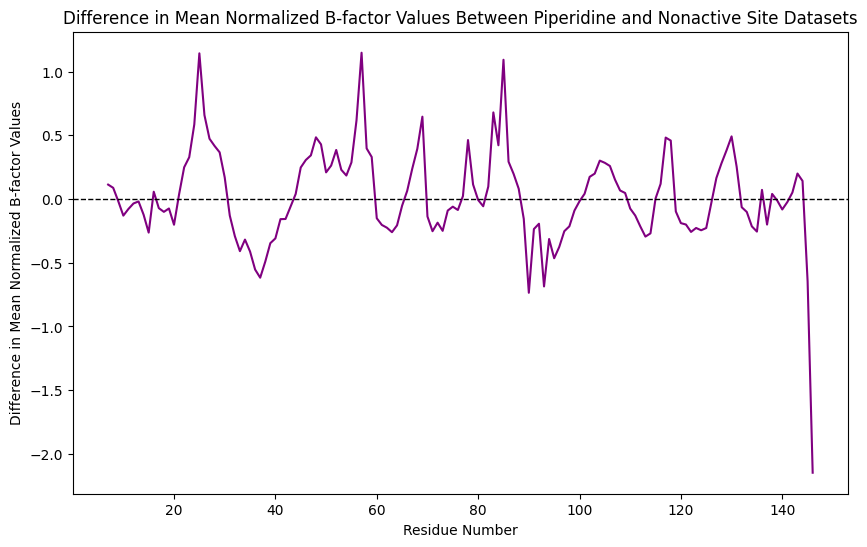

In [ ]:
plt.figure(figsize=(10,6))
plt.plot( np.arange(7, len(mean_diff)+7), mean_diff, color='purple')
plt.xlabel("Residue Number")
plt.ylabel("Difference in Mean Normalized B-factor Values")
plt.title("Difference in Mean Normalized B-factor Values Between Piperidine and Nonactive Site Datasets")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

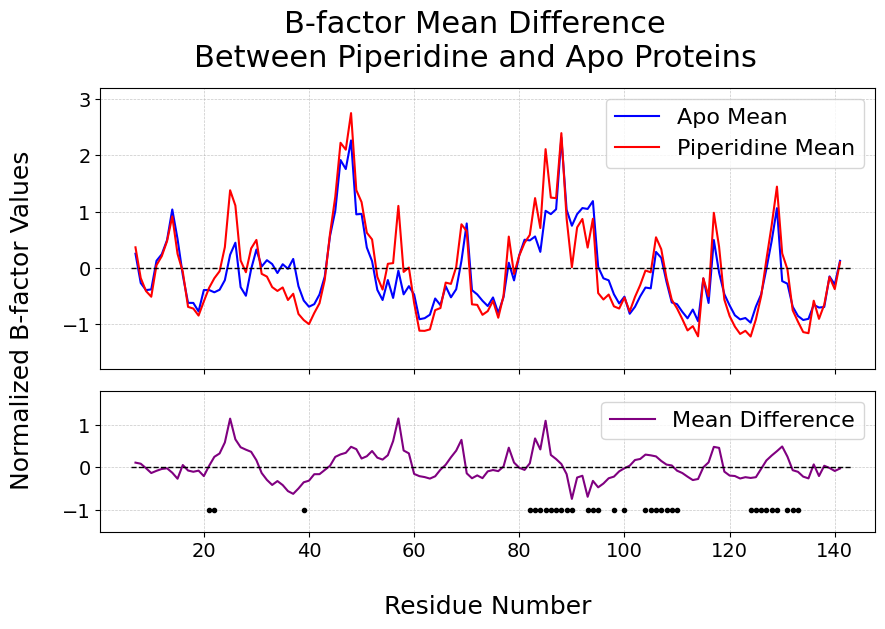

In [ ]:
# Plot b-factors Distribution
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
import matplotlib.pyplot as plt
height_ratios = [2, 1]
fig, ax  = plt.subplots(2 ,  figsize=(10,6), sharex = True, sharey= False, gridspec_kw={'height_ratios': height_ratios}) #gridspec_kw={'width_ratios': width_ratios})
residues_num = np.arange(7, len(ref_seq)+7)

for dataset_name, label, color in zip( list(all_bfactor_dict.keys())[1:],
                                      ["All Datasets", "Apo", "Piperidine"][1:], 
                                      ["green", 'blue', 'red'][1:]):
    
    bfactor_mean = all_bfactor_dict[ dataset_name ]["Normalized Values"]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["Normalized Values"]["std"]
    ax[0].plot( residues_num[:-5], bfactor_mean[:-5], label="{} Mean".format(label)
            , color= color)

    # ax[0].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["mean"][:-5], color= color, label = "Mean")
ax[0].set_ylim(-1.8, 3.2)
ax[0].tick_params( labelsize=axis_numb_size)
# Set horizontal line at y=0 starting from x=7 to the end of residues_num
ax[0].axhline( y=0, color='black', linestyle='--', linewidth=1, xmin=0.04, xmax=0.97)
# Set a grid
ax[0].grid( linestyle='--', linewidth=0.5, alpha=0.7)
ax[1].plot( residues_num[:-5], mean_diff[:-5], color = "purple", label = "Mean Difference")
ax[1].plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-1,".",  # label="Active Site",
        color= "black")
ax[1].set_ylim(-1.5, 1.8)
for i in range(2):
    ax[i].legend( fontsize=leg_size)
ax[1].set_xlabel("Residue Number", labelpad=25, fontsize=axis_size)
ax[1].set_ylabel("Normalized B-factor Values", y = 1.5, rotation=90, labelpad=20, fontsize=axis_size)
ax[1].tick_params( labelsize=axis_numb_size)
ax[1].axhline( y=0, color='black', linestyle='--', linewidth=1, xmin=0.04, xmax=0.97)
ax[1].grid( linestyle='--', linewidth=0.5, alpha=0.7)
# ax[0].set_title("Mean B-factor Distribution For Apo EV2A Proteins")
# ax[1].set_title("Standard Deviation B-factor Distribution For Apo EV2A Proteins")

plt.suptitle("B-factor Mean Difference\nBetween Piperidine and Apo Proteins", fontsize=title_size + 2)
plt.subplots_adjust(
    hspace=0.1,  # Increase vertical space (e.g., to 50% of subplot height)
#     wspace=0.3,  # Increase horizontal space (e.g., to 30% of subplot width)
    top=0.85,     # Leave space at the top for a potential super title
#     bottom=0.1
)
plt.show()

(33,)


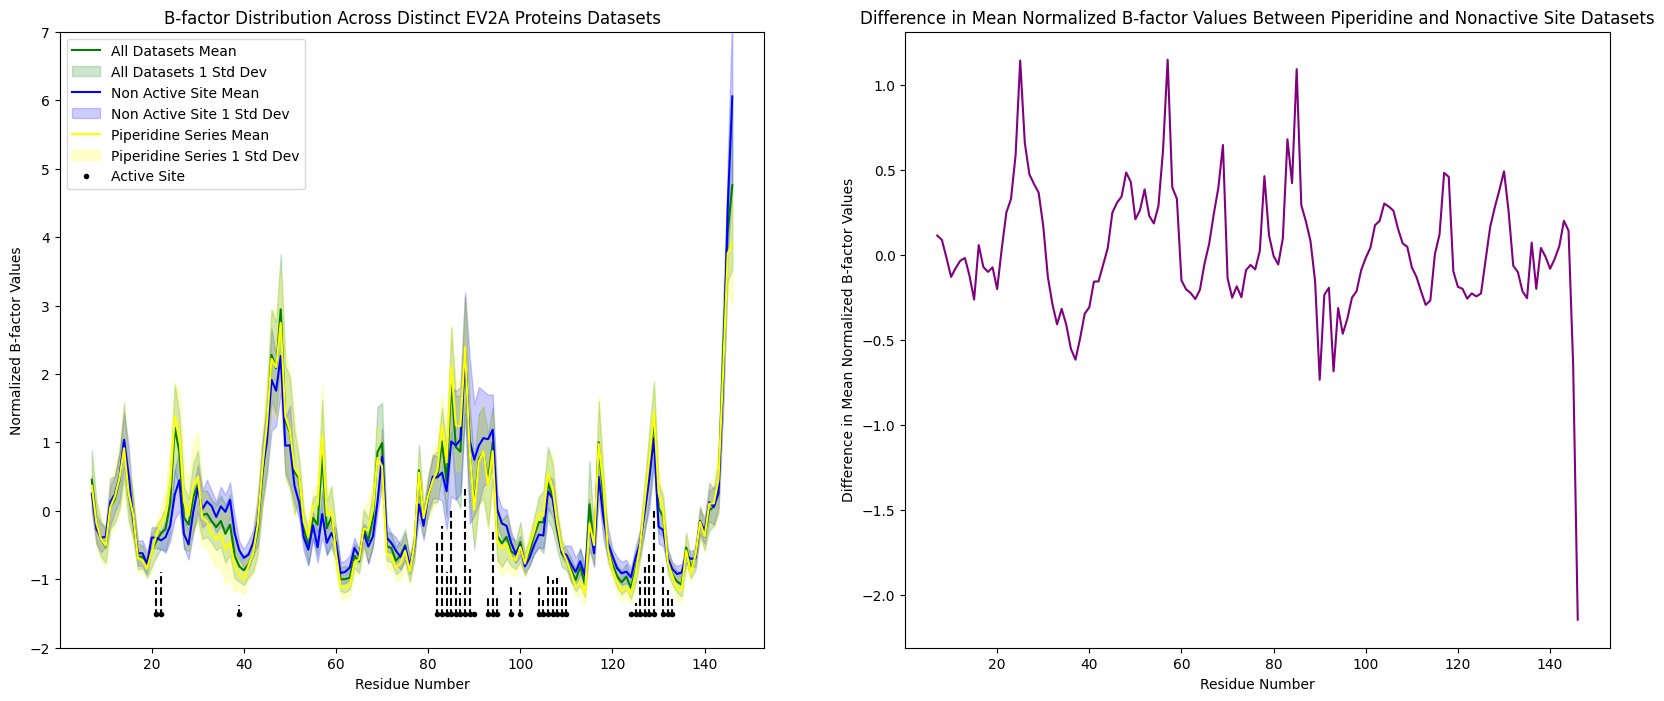

In [ ]:
# Plot b-factors Distribution
import matplotlib.pyplot as plt
active_site_res_idxs  = np.array( [14, 15, 32, 75, 76, 77, 78, 79, 80, 81, 82, 83, 86, 87, 88, 91, 93, 97, 98, 99, 100, 101, 102, 103, 117, 118, 119, 120, 121, 122, 124, 125, 126])
residues_num = np.arange(7, len(flatten_pdb( ref_prot, "residue"))+7)
fig, ax  = plt.subplots(1, 2 ,  figsize=(20,8), sharex=True)
for dataset_name, label, color in zip(all_bfactor_dict.keys(),
                                      ["All Datasets", "Non Active Site", "Piperidine Series"], 
                                      ["green", 'blue', 'yellow']):
    
    bfactor_mean = all_bfactor_dict[ dataset_name ]["Normalized Values"]["mean"]
    bfactor_std = all_bfactor_dict[ dataset_name ]["Normalized Values"]["std"]
    ax[0].plot( residues_num, bfactor_mean, label="{} Mean".format(label)
            , color= color)


    ax[0].fill_between( residues_num, bfactor_mean - bfactor_std,
                    bfactor_mean + bfactor_std, color=color, alpha=0.2,
                    label="{} 1 Std Dev".format(label) )



ax[0].plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-1.5,".",   label="Active Site".format(label)
        , color= "black")
print
x = active_site_res_idxs + 7
y_min = np.ones_like(active_site_res_idxs )*0.05 # np.ones_like(active_site_res_idxs )*-1.5 # np.ones_like(active_site_res_idxs )*-1
print(y_min.shape)
mean, std = all_bfactor_dict[ "All" ]["Normalized Values"]["mean"][active_site_res_idxs], all_bfactor_dict[ "All" ]["Normalized Values"]["std"][active_site_res_idxs]
y_max =   ( ( mean - std*2.5)   + 2)/(7 + 2)

for xi, ymin_i, ymax_i in zip(x, y_min, y_max):
    ax[0].axvline(x=xi, ymin=ymin_i, ymax=ymax_i, ls="--", color="black")


ax[0].set_ylim(-2, 7)
ax[0].set_xlabel("Residue Number")
ax[0].set_ylabel("Normalized B-factor Values")
ax[0].set_title("B-factor Distribution Across Distinct EV2A Proteins Datasets")
ax[0].legend()


ax[1].plot( np.arange(7, len(mean_diff)+7), mean_diff, color='purple')
ax[1].set_xlabel("Residue Number")
ax[1].set_ylabel("Difference in Mean Normalized B-factor Values")
ax[1].set_title("Difference in Mean Normalized B-factor Values Between Piperidine and Nonactive Site Datasets")
# ax[1].set_axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

## Get Activity Data

In [32]:
import pandas as pd
import re

metadata_df = pd.read_csv( str(rootdir.joinpath( r"data/ev2a/fragalysis/01-concatDir/metadata.csv") ) )
cdd_df = pd.read_csv( rootdir.joinpath(r"data/ev2a/cdd/cdd_v3.csv"))


regex = re.compile( "weizmann")
new_columns_names = [ col if not regex.search(col) else "WEIZMAN" + col[regex.search(col).end():] for col in  cdd_df.columns.to_list() ]
regex = re.compile( "bienta")
new_columns_names = [ col if not regex.search(col) else "BIENTA" + col[regex.search(col).end():] for col in  new_columns_names]
regex = re.compile( "X-ray_Diamond")
new_columns_names = [ col if not regex.search(col) else "X-RAY"+ col[regex.search(col).end():] for col in  new_columns_names]
cdd_df.columns = new_columns_names


piperidine_df = metadata_df[ (metadata_df[ "[Series] Piperidine series"]==True ) ] # Select piperidine entries only
piperidine_singles_df = piperidine_df[ 
                        [ not (code [:-1] + "b" in piperidine_df["Code"].values) 
                        for code in piperidine_df["Code"].values ] 
                        ]  # Select datasets with single entries only (i.e., A1259a but not A1259b, ...c, etc)
piperidine_singles_df = piperidine_singles_df[ 
                        [ len( piperidine_singles_df[piperidine_singles_df["Experiment code"] == code ] ) == 1 
                        for code in piperidine_singles_df["Experiment code"] ] ] # Double check single entry datasets only (i.e., A71EV2A-x1292 with only one entry)

pip_exp_codes = piperidine_singles_df[ [ "Experiment code"]].values.flatten()
pip_exp_codes.sort()

pip_cdd_df =  cdd_df[ cdd_df["X-RAY: Dataset"].isin( pip_exp_codes ) ]

cdd_molecname_for_frag= [ list(pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique())[0]
        if len( pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique() ) != 0
        else None
        for expcode in piperidine_singles_df["Experiment code"]   ]

piperidine_singles_df.insert(0, "CDD Molecule Name",cdd_molecname_for_frag)

def is_convertible_to_float( obj) -> bool:
    """
    Checks if a string 's' can be safely converted to a float.
    Returns True if convertible, False otherwise.
    """
    try:
        float(obj)
        return True
    except ValueError:
        return False

cdd_ic50_for_frag= [ 
        pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0] ))
    else pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0] ))
        else None
        for _, molecName in piperidine_singles_df[["Experiment code","CDD Molecule Name"]].values   ]

piperidine_singles_df.insert(1, "CDD Mean IC 50",cdd_ic50_for_frag)
# display( piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()].head(5) )
# display( piperidine_singles_df.sort_values("CDD Mean IC 50").iloc[ :, :65].head(5) )

piperidine_dataset_codes = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["Code"].tolist()
piperidine_ic50_values = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["CDD Mean IC 50"].tolist()
piperidine_ic50_values = np.array( [ float( ic50 ) for ic50 in piperidine_ic50_values ] )
# print( "Number of Piperidine Datasets with IC 50 values: ", len(piperidine_dataset_codes) )

In [34]:
piperidine_dataset_codes

['A3186a',
 'A3207a',
 'A3208a',
 'A3225a',
 'A3229a',
 'A3510a',
 'A3546a',
 'A3548a',
 'A3914a',
 'A3920a',
 'A3940a',
 'A3942a',
 'A3954a',
 'A4292a',
 'A4304a',
 'A4319a',
 'A4333a',
 'A4336a',
 'A4341a',
 'A4342a',
 'A4344a',
 'A4346a',
 'A4347a',
 'A4373a',
 'A4380a',
 'A4381a',
 'A4203a',
 'A4209a',
 'A4386a',
 'A4388a',
 'A4415a',
 'A4464a',
 'A4490a',
 'A4528a',
 'A4544a',
 'A4546a',
 'A4608a',
 'A4650a',
 'A4689a',
 'A4695a',
 'A4703a',
 'A4724a',
 'A4778a',
 'A4812a',
 'A4856a',
 'A4908a',
 'A4918a',
 'A4980a',
 'A5016a',
 'A4914a',
 'A4516a',
 'A4670a',
 'A4774a',
 'A4872a',
 'A5221a',
 'A5249a',
 'A5131a',
 'A5666a',
 'A5383a',
 'A5402a',
 'A5460a',
 'A5466a',
 'A5884a',
 'A6738a',
 'A6832a']

In [33]:
piperidine_ic50_values.shape

(65,)

## Structure to Activity Link

In [ ]:
print(pip_oneConf_names)
print( piperidine_dataset_codes )

('A7175a', 'A5460a', 'A5052a', 'A4980a', 'A5393a', 'A4809a', 'A4509a', 'A7259a', 'A4298a', 'A3585a', 'A4922a', 'A5687a', 'A3612a', 'A4812a', 'A4538a', 'A4934a', 'A4701a', 'A5277a', 'A3417a', 'A5884a', 'A4403a', 'A5222a', 'A3189a', 'A3944a', 'A3218a', 'A4894a', 'A4319a', 'A5212a', 'A4528a', 'A4839a', 'A4510a', 'A4918a', 'A4847a', 'A3488a', 'A4694a', 'A4388a', 'A4786a', 'A4546a', 'A4306a', 'A3193a', 'A4290a', 'A4778a', 'A4380a', 'A5091a', 'A3510a', 'A5231a', 'A4736a', 'A4784a', 'A5258a', 'A4994a', 'A4710a', 'A4914a', 'A3849a', 'A4748a', 'A3606a', 'A3221a', 'A4490a', 'A4346a', 'A3191a', 'A4372a', 'A4472a', 'A5073a', 'A4998a', 'A4461a', 'A4855a', 'A4304a', 'A3968a', 'A4463a', 'A4464a', 'A4571a', 'A3550a', 'A4342a', 'A5383a', 'A3936a', 'A3485a', 'A4711a', 'A3548a', 'A5065a', 'A4570a', 'A4751a', 'A4947a', 'A5466a', 'A3938a', 'A4838a', 'A4840a', 'A4791a', 'A4715a', 'A4322a', 'A4537a', 'A3480a', 'A4028a', 'A4974a', 'A3222a', 'A4341a', 'A4336a', 'A3901a', 'A3975a', 'A4381a', 'A3225a', 'A3587a',

In [ ]:
pip_oneConf_names = np.array( pip_oneConf_names )
mask = np.isin( pip_oneConf_names, piperidine_dataset_codes,  )
# print( mask )
indices  = np.where( mask )[0]
print( indices)
filtered_pip_ic50_values = all_bfactor_dict[ "Piperid" ]["Normalized Values"]["values"][ indices ]
print( filtered_pip_ic50_values.shape )

[  1   3  13  19  26  28  31  35  37  41  42  44  51  56  57  65  68  71
  72  76  81  93  94  97  98 102 105 108 116 117 121 123 127 135 136 137
 138 139 140 144 147 150 154 160 168 175 183 186 187 190 192 193 194 195
 199 201 206 207 214 215 222 226 230 237 240]
(65, 140)


In [ ]:
from scipy.stats import pearsonr
ground_bound_dif = filtered_pip_ic50_values - all_bfactor_dict[ "Nonactive" ]["Normalized Values"]["mean"]
print( ground_bound_dif.shape )
corr_per_res = np.array( [ pearsonr( ground_bound_dif[:,i], piperidine_ic50_values)[0] for i in range(ground_bound_dif.shape[1]) ] )
print( corr_per_res.shape )
print(corr_per_res)

with open(rootdir.joinpath("../pymol/pymol_vars/corr_per_res.txt"), "w") as f:
    f.write( "{}".format(  corr_per_res.tolist()) )


(65, 140)
(140,)
[-0.01855397  0.03800423  0.09543076  0.14922607  0.0655241   0.18586513
  0.16153823  0.16213988  0.13149239  0.07132593  0.08698522  0.08370409
  0.15535634  0.18335715  0.17575522  0.1710929   0.15825824  0.13722022
  0.08710221  0.19808564  0.1276891   0.19671012  0.14816459  0.12994102
  0.21739881  0.1260952   0.08710601 -0.06706811 -0.07342842 -0.12706642
 -0.0724248  -0.05105299 -0.05626692 -0.07854553  0.08920573  0.16504628
  0.13162587  0.12232273  0.08286576  0.04073159  0.02912445  0.03083637
 -0.00231676 -0.0006923  -0.05458261 -0.04689357  0.04446593  0.13735777
  0.03443237  0.02058871 -0.08214271 -0.04906819 -0.07280394 -0.1309661
  0.06821549 -0.05643542  0.08884071  0.11928058  0.22364248  0.04007146
  0.06468722 -0.07296358  0.11680374 -0.05927914  0.040432    0.05507556
  0.22066171 -0.03141105 -0.12258841  0.00109343 -0.10721139 -0.16840242
  0.03602082  0.00504169 -0.10440675 -0.16939813 -0.23115855 -0.19236711
 -0.25928587 -0.15111455 -0.1871213

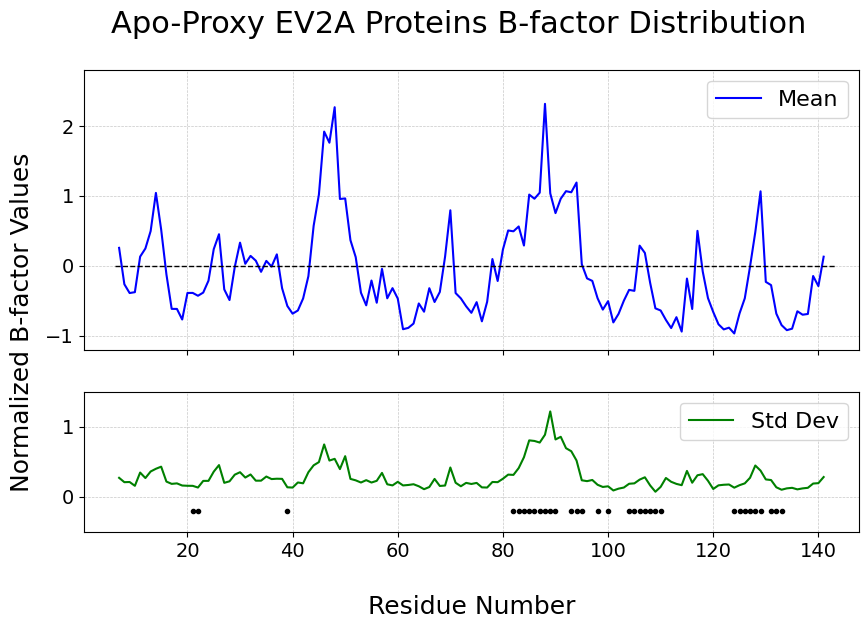

In [ ]:
# Plot b-factors Distribution
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
import matplotlib.pyplot as plt
height_ratios = [2, 1]
fig, ax  = plt.subplots(2 ,  figsize=(10,6), sharex = True, sharey= False, gridspec_kw={'height_ratios': height_ratios}) #gridspec_kw={'width_ratios': width_ratios})
residues_num = np.arange(7, len(ref_seq)+7)
ax[0].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["mean"][:-5], color= 'blue', label = "Mean")
ax[0].set_ylim(-1.2, 2.8)
ax[0].tick_params( labelsize=axis_numb_size)
# Set horizontal line at y=0 starting from x=7 to the end of residues_num
ax[0].axhline( y=0, color='black', linestyle='--', linewidth=1, xmin=0.04, xmax=0.97)
# Set a grid
ax[0].grid( linestyle='--', linewidth=0.5, alpha=0.7)
ax[1].plot( residues_num[:-5], all_bfactor_dict["Nonactive"]["Normalized Values"]["std"][:-5], color = "green", label = "Std Dev")
ax[1].plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-0.2,".",  # label="Active Site",
        color= "black")
ax[1].set_ylim(-0.5, 1.5)
for i in range(2):
    ax[i].legend( fontsize=leg_size)
ax[1].set_xlabel("Residue Number", labelpad=25, fontsize=axis_size)
ax[1].set_ylabel("Normalized B-factor Values", y = 1.5, rotation=90, labelpad=20, fontsize=axis_size)
ax[1].tick_params( labelsize=axis_numb_size)
ax[1].grid( linestyle='--', linewidth=0.5, alpha=0.7)
# ax[0].set_title("Mean B-factor Distribution For Apo EV2A Proteins")
# ax[1].set_title("Standard Deviation B-factor Distribution For Apo EV2A Proteins")

plt.suptitle("Apo-Proxy EV2A Proteins B-factor Distribution", fontsize=title_size + 2)
plt.show()

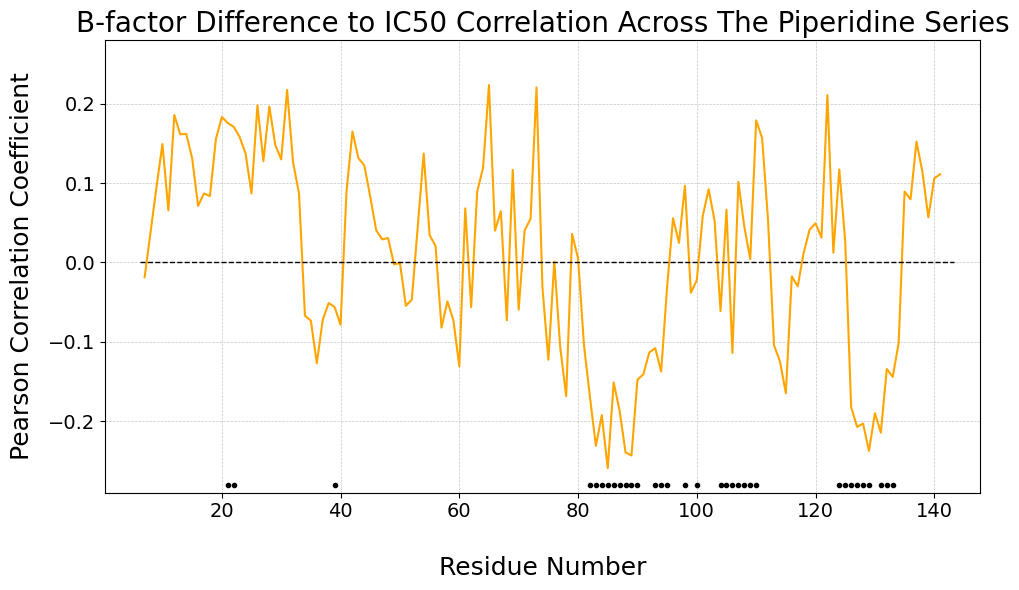

In [ ]:
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
plt.figure(figsize=(10,6))
plt.plot( np.arange(7, len(corr_per_res)+7)[:-5], corr_per_res[:-5], color='orange')
plt.plot( active_site_res_idxs + 7, np.ones_like(active_site_res_idxs )*-0.28,".",  # label="Active Site",
        color= "black")
plt.xlabel("Residue Number", fontsize=axis_size, labelpad= 25)
plt.ylabel("Pearson Correlation Coefficient", fontsize=axis_size, labelpad = 10 )
plt.title("B-factor Difference to IC50 Correlation Across The Piperidine Series", fontsize=title_size )
plt.axhline( y=0, color='black', linestyle='--', linewidth=1, xmin=0.04, xmax=0.97)
plt.grid( linestyle='--', linewidth=0.5, alpha=0.7)
plt.ylim(-0.29, 0.28)
plt.tick_params( labelsize=axis_numb_size)
plt.tight_layout()
plt.show()

In [ ]:
print(ground_bound_dif[0][active_site_res_idxs])


[-0.0182787   0.50933403 -0.45718892 -0.16896698  0.74438292  0.61360237
  1.35543607  0.3419702   0.18793114  0.26308077 -0.01915587 -0.85316141
 -0.93781175 -0.4442045  -0.74687784 -0.34398306  0.11208476  0.43161726
  0.31722125  0.459152    0.10114236  0.23493775  0.21546793 -0.04190624
 -0.20829656 -0.1298582   0.22208565  0.57177836  0.66028809  0.47869198
  0.50187202  0.10129784 -0.20278115]


In [ ]:

ground_bound_dif
mean_all_ground_bound_dif = np.nanmean(ground_bound_dif, axis = 1)
active_site_ground_bound_dif = np.array([ arr[active_site_res_idxs] for arr in ground_bound_dif] )
mean_active_site_ground_bound_dif = np.nanmean(active_site_ground_bound_dif, axis = 1)

print(ground_bound_dif.shape)
print( mean_all_ground_bound_dif.shape)
print(active_site_ground_bound_dif.shape)
print(mean_active_site_ground_bound_dif.shape)
print(piperidine_ic50_values.shape)

(65, 140)
(65,)
(65, 33)
(65,)
(65,)


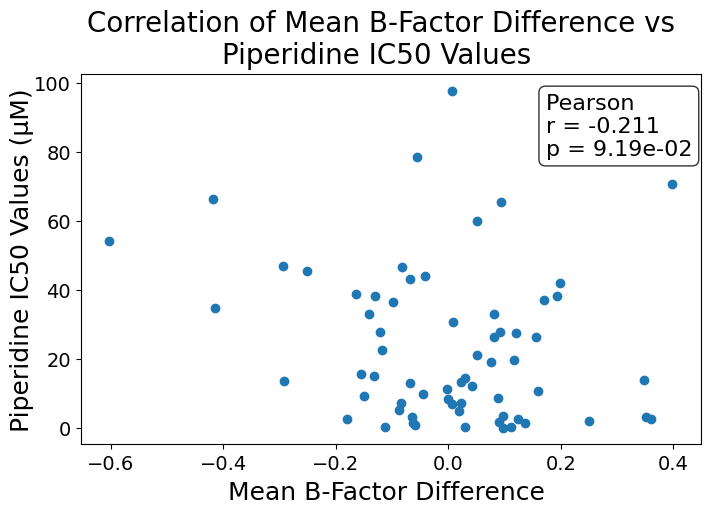

In [ ]:
axis_numb_size, leg_size, axis_size, title_size = 14, 16, 18, 20, 
fig, ax = plt.subplots( 1, figsize = [8, 5], sharex=False, sharey=True )
y = piperidine_ic50_values
for idx, (x, label, bin )in enumerate( zip([mean_all_ground_bound_dif, mean_active_site_ground_bound_dif][1:],
                                              ["All", "Active Site"][1:],
                                              [70, 10][1:])):
    
    ax.scatter( x,  y , )
    ax.set_xlabel("Mean B-Factor Difference ",  fontsize=axis_size, labelpad= 5)
    ax.set_ylabel( "Piperidine IC50 Values (µM)",  fontsize=axis_size, labelpad= 0)
    # ax.set_title("Correlation for {} Data".format(label))


    r, p = pearsonr(x, y)
    ax.text(
    0.75, 0.95,
    f"Pearson \nr = {r:.3f}\np = {p:.2e}",
    transform=ax.transAxes,
    fontsize=leg_size,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    ax.tick_params( labelsize=axis_numb_size)

plt.subplots_adjust(
    hspace=0.1,  # Increase vertical space (e.g., to 50% of subplot height)
#     wspace=0.3,  # Increase horizontal space (e.g., to 30% of subplot width)
    top=0.85,     # Leave space at the top for a potential super title
#     bottom=0.1
)

plt.suptitle( "Correlation of Mean B-Factor Difference vs\nPiperidine IC50 Values ",  fontsize= title_size)
plt.show()
